# Andre marroquin 22266
# Librerias importarlas

In [ ]:
# imports de las librerias principales
import os
import re
import math
import json
import time
import hashlib
import warnings
from itertools import combinations
import numpy as np
import pandas as pd
import pefile
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn_extra.cluster import KMedoids
from google import genai
from google.genai import types

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

# rutas principales

In [ ]:
# se definen las rutas para salidas y entrads
RutaDataset = "./MALWR"
RutaSalida = "./salidasLab3"
RutaGraficas = os.path.join(RutaSalida, "graficas")
RutaGrafos = os.path.join(RutaSalida, "grafos")
RutaTablas = os.path.join(RutaSalida, "tablas")

os.makedirs(RutaSalida, exist_ok=True)
os.makedirs(RutaGraficas, exist_ok=True)
os.makedirs(RutaGrafos, exist_ok=True)
os.makedirs(RutaTablas, exist_ok=True)

ListaUmbrales = [0.60, 0.80, 0.95]
RangoK = list(range(2, 11))
Semilla = 42
LongitudMinimaString = 4
MaxStringsDocumento = 250
MaxFuncionesDocumento = 200
MaxDllDocumento = 80
MaxSeccionesDocumento = 20
ModeloGeminiEmbeddings = "gemini-embedding-001"

print("Ruta dataset:", RutaDataset)
print("Ruta salida:", RutaSalida)

Ruta dataset: ./MALWR
Ruta salida: ./salidasLab3


# Funciones base para validacion entropia hashing y similitud

In [ ]:
# si el archivo puede ser un PE por cabecera MZ
def esEjecutablePe(rutaArchivo: str) -> bool:
    try:
        with open(rutaArchivo, "rb") as archivo:
            cabecera = archivo.read(2)
        return cabecera == b"MZ"
    except Exception:
        return False


# entropia de Shannon de un bloque de bytes
def calcularEntropiaBytes(datos: bytes) -> float:
    if not datos:
        return 0.0
    arreglo = np.frombuffer(datos, dtype=np.uint8)
    conteos = np.bincount(arreglo, minlength=256)
    probabilidades = conteos / len(arreglo)
    probabilidades = probabilidades[probabilidades > 0]
    return float(-(probabilidades * np.log2(probabilidades)).sum())


# convierte lista de tokens a conjunto limpio
def listaAConjunto(listaValores: list[str]) -> set[str]:
    salida = set()
    for valor in listaValores:
        if valor is None:
            continue
        token = str(valor).strip().lower()
        if token:
            salida.add(token)
    return salida


# calcula indice de Jaccard entre dos conjuntos
def jaccardConjuntos(conjuntoA: set[str], conjuntoB: set[str]) -> float:
    if not conjuntoA and not conjuntoB:
        return 1.0
    if not conjuntoA or not conjuntoB:
        return 0.0
    interseccion = len(conjuntoA.intersection(conjuntoB))
    union = len(conjuntoA.union(conjuntoB))
    if union == 0:
        return 0.0
    return float(interseccion / union)


# jala el hash sha256 del archivo para identificarlo
def calcularSha256Archivo(rutaArchivo: str) -> str:
    try:
        hashSha256 = hashlib.sha256()
        with open(rutaArchivo, "rb") as archivo:
            for bloque in iter(lambda: archivo.read(1024 * 1024), b""):
                hashSha256.update(bloque)
        return hashSha256.hexdigest()
    except Exception:
        return ""


# extrae strings ASCII imprimibles desde bytes del binario
def extraerStringsBinario(rutaArchivo: str, longitudMinima: int = 4) -> list[str]:
    try:
        with open(rutaArchivo, "rb") as archivo:
            datos = archivo.read()
        patron = rb"[ -~]{" + str(longitudMinima).encode() + rb",}"
        encontrados = re.findall(patron, datos)
        stringsLimpios = []
        for valor in encontrados:
            try:
                texto = valor.decode("utf-8", errors="ignore").strip().lower()
                if texto:
                    stringsLimpios.append(texto)
            except Exception:
                continue
        return stringsLimpios
    except Exception:
        return []


#  empaquetado de forma heuristica por nombres y entropia
def estaEmpaquetadoHeuristico(rutaArchivo: str, umbralEntropia: float = 7.2) -> bool:
    try:
        pe = pefile.PE(rutaArchivo, fast_load=True)
        nombresSospechosos = {"upx", "aspack", "fsg", "mpress", "petite", "themida", "pecompact", "vmp", "vmprotect"}
        totalSecciones = 0
        seccionesAltas = 0
        banderaNombre = False

        for seccion in getattr(pe, "sections", []):
            totalSecciones += 1
            nombre = seccion.Name.decode(errors="ignore").strip("\x00").lower()
            if any(valor in nombre for valor in nombresSospechosos):
                banderaNombre = True
            datos = seccion.get_data() or b""
            entropia = calcularEntropiaBytes(datos)
            if entropia >= umbralEntropia:
                seccionesAltas += 1

        pe.close()

        if banderaNombre:
            return True
        if totalSecciones > 0 and (seccionesAltas / totalSecciones) >= 0.5:
            return True
        return False
    except Exception:
        return False

# Funciones para extraccion de metadatos PE y construccion del dataset

In [ ]:
# saca toda metadata PE, imports, dlls y secciones sin ejecutar el archivo
def extraerMetadatosPe(rutaArchivo: str) -> dict:
    resultado = {
        "esPe": False,
        "tamanoBytes": 0,
        "sha256": "",
        "machine": "",
        "compiladoEpoch": 0,
        "numeroSecciones": 0,
        "entryPoint": 0,
        "imageBase": 0,
        "subsystem": 0,
        "dll": 0,
        "aslr": 0,
        "dep": 0,
        "numeroImports": 0,
        "numeroDlls": 0,
        "numeroExports": 0,
        "numeroRecursos": 0,
        "numeroStrings": 0,
        "entropiaArchivo": 0.0,
        "entropiaPromedioSecciones": 0.0,
        "empaquetadoHeuristico": 0,
        "seccionesTexto": "",
        "dllsTexto": "",
        "funcionesTexto": "",
    }

    try:
        resultado["tamanoBytes"] = os.path.getsize(rutaArchivo)
    except Exception:
        resultado["tamanoBytes"] = 0

    resultado["sha256"] = calcularSha256Archivo(rutaArchivo)

    try:
        with open(rutaArchivo, "rb") as archivo:
            datosArchivo = archivo.read()
        resultado["entropiaArchivo"] = calcularEntropiaBytes(datosArchivo)
    except Exception:
        resultado["entropiaArchivo"] = 0.0

    if not esEjecutablePe(rutaArchivo):
        return resultado

    try:
        pe = pefile.PE(rutaArchivo, fast_load=False)
        resultado["esPe"] = True
        resultado["machine"] = hex(int(pe.FILE_HEADER.Machine))
        resultado["compiladoEpoch"] = int(pe.FILE_HEADER.TimeDateStamp)
        resultado["numeroSecciones"] = int(pe.FILE_HEADER.NumberOfSections)
        resultado["entryPoint"] = int(pe.OPTIONAL_HEADER.AddressOfEntryPoint)
        resultado["imageBase"] = int(pe.OPTIONAL_HEADER.ImageBase)
        resultado["subsystem"] = int(pe.OPTIONAL_HEADER.Subsystem)
        resultado["dll"] = int(bool(pe.FILE_HEADER.Characteristics & 0x2000))
        resultado["aslr"] = int(bool(pe.OPTIONAL_HEADER.DllCharacteristics & 0x0040))
        resultado["dep"] = int(bool(pe.OPTIONAL_HEADER.DllCharacteristics & 0x0100))
        resultado["empaquetadoHeuristico"] = int(estaEmpaquetadoHeuristico(rutaArchivo))

        listaSecciones = []
        listaEntropias = []

        for seccion in getattr(pe, "sections", []):
            nombreSeccion = seccion.Name.decode(errors="ignore").strip("\x00").lower()
            if nombreSeccion:
                listaSecciones.append(nombreSeccion)
            datosSeccion = seccion.get_data() or b""
            listaEntropias.append(calcularEntropiaBytes(datosSeccion))

        if listaEntropias:
            resultado["entropiaPromedioSecciones"] = float(np.mean(listaEntropias))
        resultado["seccionesTexto"] = " ".join(sorted(set(listaSecciones))[:MaxSeccionesDocumento])

        listaDlls = []
        listaFunciones = []

        pe.parse_data_directories(
            directories=[
                pefile.DIRECTORY_ENTRY["IMAGE_DIRECTORY_ENTRY_IMPORT"],
                pefile.DIRECTORY_ENTRY["IMAGE_DIRECTORY_ENTRY_EXPORT"],
                pefile.DIRECTORY_ENTRY["IMAGE_DIRECTORY_ENTRY_RESOURCE"],
            ]
        )

        if hasattr(pe, "DIRECTORY_ENTRY_IMPORT"):
            for entrada in pe.DIRECTORY_ENTRY_IMPORT:
                nombreDll = entrada.dll.decode(errors="ignore").lower() if entrada.dll else ""
                if nombreDll:
                    listaDlls.append(nombreDll)
                for funcion in entrada.imports:
                    if funcion.name:
                        nombreFuncion = funcion.name.decode(errors="ignore").lower()
                        listaFunciones.append(f"{nombreDll}:{nombreFuncion}")

        resultado["numeroImports"] = int(len(listaFunciones))
        resultado["numeroDlls"] = int(len(set(listaDlls)))
        resultado["dllsTexto"] = " ".join(sorted(set(listaDlls))[:MaxDllDocumento])
        resultado["funcionesTexto"] = " ".join(sorted(set(listaFunciones))[:MaxFuncionesDocumento])

        if hasattr(pe, "DIRECTORY_ENTRY_EXPORT") and getattr(pe, "DIRECTORY_ENTRY_EXPORT", None) is not None:
            simbolos = getattr(pe.DIRECTORY_ENTRY_EXPORT, "symbols", [])
            resultado["numeroExports"] = int(len(simbolos))

        if hasattr(pe, "DIRECTORY_ENTRY_RESOURCE") and getattr(pe, "DIRECTORY_ENTRY_RESOURCE", None) is not None:
            try:
                resultado["numeroRecursos"] = int(len(pe.DIRECTORY_ENTRY_RESOURCE.entries))
            except Exception:
                resultado["numeroRecursos"] = 0

        pe.close()
        return resultado

    except Exception:
        return resultado


# crea doc a partir de strings e imports para NLP y embeddings
def construirDocumentoAnalisis(stringsLista: list[str], funcionesLista: list[str], dllsTexto: str, seccionesTexto: str) -> str:
    stringsTop = stringsLista[:MaxStringsDocumento]
    funcionesTop = funcionesLista[:MaxFuncionesDocumento]
    partes = [
        "strings " + " ".join(stringsTop),
        "funciones " + " ".join(funcionesTop),
        "dlls " + str(dllsTexto),
        "secciones " + str(seccionesTexto),
    ]
    documento = " ".join(partes).strip().lower()
    documento = re.sub(r"\s+", " ", documento)
    return documento


# recorre el dataset y arma un dataframe completo para clustering y similitud
def construirDatasetMalware(rutaDataset: str, longitudMinimaString: int = 4) -> pd.DataFrame:
    filas = []

    for raiz, _, archivos in os.walk(rutaDataset):
        for nombreArchivo in sorted(archivos):
            rutaArchivo = os.path.join(raiz, nombreArchivo)

            if not os.path.isfile(rutaArchivo):
                continue

            if not esEjecutablePe(rutaArchivo):
                continue

            metadatos = extraerMetadatosPe(rutaArchivo)
            stringsLista = extraerStringsBinario(rutaArchivo, longitudMinima=longitudMinimaString)

            funcionesLista = []
            if metadatos["funcionesTexto"]:
                funcionesLista = metadatos["funcionesTexto"].split()

            documentoAnalisis = construirDocumentoAnalisis(
                stringsLista=stringsLista,
                funcionesLista=funcionesLista,
                dllsTexto=metadatos["dllsTexto"],
                seccionesTexto=metadatos["seccionesTexto"],
            )

            fila = {
                "rutaArchivo": rutaArchivo,
                "nombreArchivo": nombreArchivo,
                "sha256": metadatos["sha256"],
                "tamanoBytes": metadatos["tamanoBytes"],
                "esPe": int(metadatos["esPe"]),
                "machine": metadatos["machine"],
                "compiladoEpoch": metadatos["compiladoEpoch"],
                "numeroSecciones": metadatos["numeroSecciones"],
                "entryPoint": metadatos["entryPoint"],
                "imageBase": metadatos["imageBase"],
                "subsystem": metadatos["subsystem"],
                "dll": metadatos["dll"],
                "aslr": metadatos["aslr"],
                "dep": metadatos["dep"],
                "numeroImports": metadatos["numeroImports"],
                "numeroDlls": metadatos["numeroDlls"],
                "numeroExports": metadatos["numeroExports"],
                "numeroRecursos": metadatos["numeroRecursos"],
                "numeroStrings": len(stringsLista),
                "entropiaArchivo": metadatos["entropiaArchivo"],
                "entropiaPromedioSecciones": metadatos["entropiaPromedioSecciones"],
                "empaquetadoHeuristico": metadatos["empaquetadoHeuristico"],
                "seccionesTexto": metadatos["seccionesTexto"],
                "dllsTexto": metadatos["dllsTexto"],
                "funcionesTexto": metadatos["funcionesTexto"],
                "stringsTexto": " ".join(stringsLista[:MaxStringsDocumento]),
                "documentoAnalisis": documentoAnalisis,
            }
            filas.append(fila)

    dataframe = pd.DataFrame(filas)
    if not dataframe.empty:
        dataframe = dataframe.sort_values(["nombreArchivo"]).reset_index(drop=True)
    return dataframe

# Creacion y guardado del dataset de malware

In [ ]:
# se crea el dataset y se guarda
DfDataset = construirDatasetMalware(RutaDataset, longitudMinimaString=LongitudMinimaString)

RutaCsvDataset = os.path.join(RutaTablas, "datasetMalware.csv")
DfDataset.to_csv(RutaCsvDataset, index=False, encoding="utf-8")

print("Total de muestras:", len(DfDataset))
print("Dataset guardado en:", RutaCsvDataset)
DfDataset.head(10)

Total de muestras: 40
Dataset guardado en: ./salidasLab3/tablas/datasetMalware.csv


,rutaArchivo,nombreArchivo,sha256,tamanoBytes,esPe,machine,compiladoEpoch,numeroSecciones,entryPoint,imageBase,subsystem,dll,aslr,dep,numeroImports,numeroDlls,numeroExports,numeroRecursos,numeroStrings,entropiaArchivo,entropiaPromedioSecciones,empaquetadoHeuristico,seccionesTexto,dllsTexto,funcionesTexto,stringsTexto,documentoAnalisis
0,./MALWR/1F2EB7B090018D975E6D9B40868C94CA,1F2EB7B090018D975E6D9B40868C94CA,0a76f1439cc52fed9e9627f82686c6daedefcf191952ae2c8e5879f1332711b8,5120,1,0x14c,1263576056,3,27632,4194304,2,0,0,0,7,4,0,1,89,6.493045,3.379585,1,.rsrc upx0 upx1,kernel32.dll msvcrt.dll user32.dll ws2_32.dll,kernel32.dll:exitprocess kernel32.dll:getprocaddress kernel32.dll:loadlibrarya kernel32.dll:virtualprotect msvcrt.dl...,!this program cannot be run in dos mode. rich upx0 upx1 .rsrc 3.96 upx! m{{v _^][ vws. l40!f ; rpx48 w0fi 3xex rdqp ...,strings !this program cannot be run in dos mode. rich upx0 upx1 .rsrc 3.96 upx! m{{v _^][ vws. l40!f ; rpx48 w0fi 3x...
1,./MALWR/33DE5067A433A6EC5C328067DC18EC37,33DE5067A433A6EC5C328067DC18EC37,2512c61f77b21ec2847379453b3035f6e23ab77d8ab092ceb06ed907c6d83c98,5632,1,0x14c,1195429813,3,28048,4194304,2,0,0,0,8,5,0,1,107,6.596264,3.507004,1,.rsrc upx0 upx1,kernel32.dll msvcrt.dll shell32.dll user32.dll ws2_32.dll,kernel32.dll:exitprocess kernel32.dll:getprocaddress kernel32.dll:loadlibrarya kernel32.dll:virtualprotect msvcrt.dl...,"!this program cannot be run in dos mode. richo upx0 upx1 .rsrc 3.96 upx! m{{v _^][ vws. ,!f ; $terpi44 #<eb c,fv tvt...","strings !this program cannot be run in dos mode. richo upx0 upx1 .rsrc 3.96 upx! m{{v _^][ vws. ,!f ; $terpi44 #<eb ..."
2,./MALWR/65018CD542145A3792BA09985734C12A,65018CD542145A3792BA09985734C12A,4086f0a4f2a15c4e5896a158950e13c9350b4d9e850a0f06e166fe3d04964d42,5632,1,0x14c,1195429813,3,28048,4194304,2,0,0,0,8,5,0,1,109,6.594506,3.506502,1,.rsrc upx0 upx1,kernel32.dll msvcrt.dll shell32.dll user32.dll ws2_32.dll,kernel32.dll:exitprocess kernel32.dll:getprocaddress kernel32.dll:loadlibrarya kernel32.dll:virtualprotect msvcrt.dl...,"!this program cannot be run in dos mode. richo upx0 upx1 .rsrc 3.96 upx! s+^j m{{v _^][ vws. ,!f ; $terpi44 #<eb c,f...","strings !this program cannot be run in dos mode. richo upx0 upx1 .rsrc 3.96 upx! s+^j m{{v _^][ vws. ,!f ; $terpi44 ..."
3,./MALWR/650A6FCA433EE243391E4B4C11F09438,650A6FCA433EE243391E4B4C11F09438,08c41e549dd5d125860b8aa2b9e0c8b736e068a177cf8aa695be7dc9f8fadc31,5632,1,0x14c,1242321160,3,28064,4194304,2,0,0,0,8,5,0,1,111,6.603342,3.508176,1,.rsrc upx0 upx1,kernel32.dll msvcrt.dll shell32.dll user32.dll ws2_32.dll,kernel32.dll:exitprocess kernel32.dll:getprocaddress kernel32.dll:loadlibrarya kernel32.dll:virtualprotect msvcrt.dl...,!this program cannot be run in dos mode. richo upx0 upx1 .rsrc 3.96 upx! m{{v _^][ vws. l40!f ; rpx48 u!cg |0fn )xvx...,strings !this program cannot be run in dos mode. richo upx0 upx1 .rsrc 3.96 upx! m{{v _^][ vws. l40!f ; rpx48 u!cg |...
4,./MALWR/6FAA4740F99408D4D2DDDD0B09BBDEFD,6FAA4740F99408D4D2DDDD0B09BBDEFD,41e14883b3a545de6c34c1f14d3856d0e070af9aee7d3b09dbb57552934cede4,5632,1,0x14c,1242321160,3,28064,4194304,2,0,0,0,8,5,0,1,118,6.604928,3.508873,1,.rsrc upx0 upx1,kernel32.dll msvcrt.dll shell32.dll user32.dll ws2_32.dll,kernel32.dll:exitprocess kernel32.dll:getprocaddress kernel32.dll:loadlibrarya kernel32.dll:virtualprotect msvcrt.dl...,!this program cannot be run in dos mode. richo upx0 upx1 .rsrc 3.96 upx! m{{v _^][ vws. l40!f ; rpx48 u!cg |0fn )xvx...,strings !this program cannot be run in dos mode. richo upx0 upx1 .rsrc 3.96 upx! m{{v _^][ vws. l40!f ; rpx48 u!cg |...
5,./MALWR/785003A405BC7A4EBCBB21DDB757BF3F,785003A405BC7A4EBCBB21DDB757BF3F,cefb1bc23f66a70f87bc12d9cd9b23264e66338d1b508c56342b59cc1c06cf21,5632,1,0x14c,1242321160,3,28064,4194304,2,0,0,0,8,5,0,1,117,6.608424,3.510551,1,.rsrc upx0 upx1,kernel32.dll msvcrt.dll shell32.dll user32.dll ws2_32.dll,kernel32.dll:exitprocess kernel32.dll:getprocaddress kernel32.dll:loadlibrarya kernel32.dll:virtua

# Exploracion inicial de dataset

In [ ]:
# Eda para entender el dataset antes del clustering
def resumirDataset(dataframe: pd.DataFrame) -> pd.DataFrame:
    filas = []

    for columna in dataframe.columns:
        serie = dataframe[columna]
        fila = {
            "columna": columna,
            "tipo": str(serie.dtype),
            "nulos": int(serie.isna().sum()),
            "unicos": int(serie.nunique(dropna=True)),
        }

        if pd.api.types.is_numeric_dtype(serie):
            fila["min"] = float(serie.min()) if len(serie) else 0.0
            fila["max"] = float(serie.max()) if len(serie) else 0.0
            fila["media"] = float(serie.mean()) if len(serie) else 0.0
        else:
            fila["min"] = None
            fila["max"] = None
            fila["media"] = None

        filas.append(fila)

    return pd.DataFrame(filas)


# crea columnas auxiliares para preprocesamiento y analisis
def enriquecerDataset(dataframe: pd.DataFrame) -> pd.DataFrame:
    copia = dataframe.copy()

    copia["logTamanoBytes"] = np.log1p(copia["tamanoBytes"])
    copia["logNumeroStrings"] = np.log1p(copia["numeroStrings"])
    copia["logNumeroImports"] = np.log1p(copia["numeroImports"])
    copia["logNumeroDlls"] = np.log1p(copia["numeroDlls"])
    copia["logNumeroSecciones"] = np.log1p(copia["numeroSecciones"])
    copia["textoCabecera"] = (
        "machine " + copia["machine"].astype(str) + " " +
        "subsystem " + copia["subsystem"].astype(str) + " " +
        "dll " + copia["dll"].astype(str) + " " +
        "aslr " + copia["aslr"].astype(str) + " " +
        "dep " + copia["dep"].astype(str)
    )
    copia["documentoCompleto"] = (
        copia["documentoAnalisis"].fillna("") + " " + copia["textoCabecera"].fillna("")
    ).str.strip()

    return copia


DfDataset = enriquecerDataset(DfDataset)
DfResumenColumnas = resumirDataset(DfDataset)
DfResumenColumnas

,columna,tipo,nulos,unicos,min,max,media
0,rutaArchivo,object,0,40,NaN,NaN,NaN
1,nombreArchivo,object,0,40,NaN,NaN,NaN
2,sha256,object,0,40,NaN,NaN,NaN
3,tamanoBytes,int64,0,9,5.120000e+03,3.481600e+05,7.221760e+04
4,esPe,int64,0,1,1.000000e+00,1.000000e+00,1.000000e+00
5,machine,object,0,1,NaN,NaN,NaN
6,compiladoEpoch,int64,0,15,1.195430e+09,1.319016e+09,1.268479e+09
7,numeroSecciones,int64,0,2,3.000000e+00,4.000000e+00,3.025000e+00
8,entryPoint,int64,0,11,2.763200e+04,3.422618e+09,6.848401e+08
9,imageBase,int64,0,2,4.194304e+06,2.684355e+08,3.722445e+07


# Preparacion de variables y preprocesamiento para clustering

In [ ]:
# prepara las variables para preprocesamietno
ColumnasNumericas = [
    "logTamanoBytes",
    "logNumeroStrings",
    "logNumeroImports",
    "logNumeroDlls",
    "logNumeroSecciones",
    "numeroExports",
    "numeroRecursos",
    "entryPoint",
    "imageBase",
    "entropiaArchivo",
    "entropiaPromedioSecciones",
    "dll",
    "aslr",
    "dep",
    "empaquetadoHeuristico",
]

ColumnasTexto = [
    "documentoCompleto",
]

XEntrada = DfDataset[ColumnasNumericas + ColumnasTexto].copy()

Preprocesador = ColumnTransformer(
    transformers=[
        ("numerico", StandardScaler(), ColumnasNumericas),
        (
            "texto",
            TfidfVectorizer(
                lowercase=True,
                token_pattern=r"(?u)\b[\w\.\-\:]{2,}\b",
                max_features=2500,
                ngram_range=(1, 2),
                min_df=1,
                max_df=0.95,
            ),
            "documentoCompleto",
        ),
    ],
    remainder="drop",
)

XMatriz = Preprocesador.fit_transform(XEntrada)

print("Forma matriz de features:", XMatriz.shape)

Forma matriz de features: (40, 2515)


# Funciones para evaluar algoritmos de particionamiento

In [ ]:
# corre KMeans y KMedoids en un rango de k y devuelve metricas de codo y silhouette
def evaluarAlgoritmoParticion(matriz, listaK: list[int], nombreAlgoritmo: str, semilla: int = 42) -> tuple[pd.DataFrame, dict]:
    filas = []
    modelos = {}

    for k in listaK:
        if nombreAlgoritmo.lower() == "kmeans":
            modelo = KMeans(
                n_clusters=k,
                random_state=semilla,
                n_init=20,
                max_iter=500,
            )
            etiquetas = modelo.fit_predict(matriz)
            errorCodo = float(modelo.inertia_)

        elif nombreAlgoritmo.lower() == "kmedoids":
            modelo = KMedoids(
                n_clusters=k,
                random_state=semilla,
                metric="euclidean",
                init="k-medoids++",
            )
            etiquetas = modelo.fit_predict(matriz)
            try:
                errorCodo = float(modelo.inertia_)
            except Exception:
                errorCodo = float("nan")
        else:
            raise ValueError("Algoritmo no soportado")

        puntajeSilhouette = float(silhouette_score(matriz, etiquetas))
        muestrasSilhouette = silhouette_samples(matriz, etiquetas)
        promedioPorCluster = []

        for clusterId in sorted(set(etiquetas)):
            promedioCluster = float(np.mean(muestrasSilhouette[etiquetas == clusterId]))
            promedioPorCluster.append(promedioCluster)

        fila = {
            "algoritmo": nombreAlgoritmo,
            "k": int(k),
            "errorCodo": errorCodo,
            "silhouette": puntajeSilhouette,
            "silhouetteMinCluster": float(np.min(promedioPorCluster)),
            "silhouettePromedioClusters": float(np.mean(promedioPorCluster)),
        }
        filas.append(fila)
        modelos[k] = {
            "modelo": modelo,
            "etiquetas": etiquetas,
            "silhouetteMuestras": muestrasSilhouette,
        }

    return pd.DataFrame(filas), modelos


# grafica la curva de codo y silhouette para un algoritmo
def graficarMetricasParticion(dataframeMetricas: pd.DataFrame, nombreAlgoritmo: str, rutaSalida: str) -> None:
    figura = plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(dataframeMetricas["k"], dataframeMetricas["errorCodo"], marker="o")
    plt.title(f"Codo {nombreAlgoritmo}")
    plt.xlabel("K")
    plt.ylabel("Error")

    plt.subplot(1, 2, 2)
    plt.plot(dataframeMetricas["k"], dataframeMetricas["silhouette"], marker="o")
    plt.title(f"Silhouette {nombreAlgoritmo}")
    plt.xlabel("K")
    plt.ylabel("Silhouette")

    plt.tight_layout()
    plt.savefig(rutaSalida, dpi=200, bbox_inches="tight")
    plt.show()


# elige el mejor k segun silhouette maximo
def obtenerMejorKPorSilhouette(dataframeMetricas: pd.DataFrame) -> int:
    mejorFila = dataframeMetricas.sort_values(["silhouette", "k"], ascending=[False, True]).iloc[0]
    return int(mejorFila["k"])

# Evaluacion de KMeans con metodo del codo y Silhouette

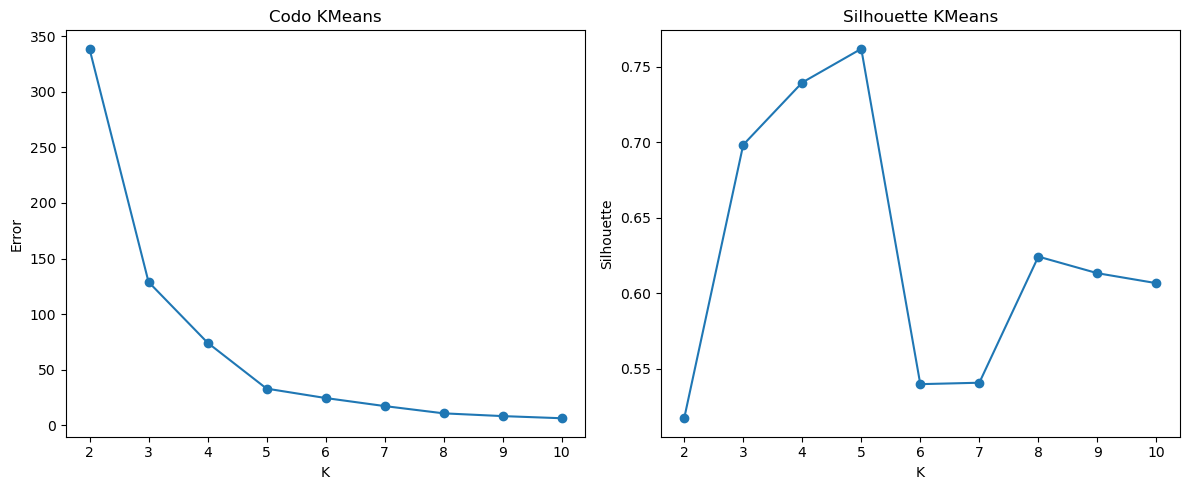

Mejor K KMeans segun silhouette: 5


,algoritmo,k,errorCodo,silhouette,silhouetteMinCluster,silhouettePromedioClusters
0,KMeans,2,338.553214,0.517337,0.439066,0.487986
1,KMeans,3,128.928998,0.698315,0.406160,0.635638
2,KMeans,4,74.327801,0.739556,0.673819,0.732296
3,KMeans,5,33.041774,0.761858,0.000000,0.631565
4,KMeans,6,24.575484,0.539905,0.000000,0.551473
5,KMeans,7,17.344782,0.540850,0.000000,0.567454
6,KMeans,8,10.804719,0.624331,0.000000,0.624710
7,KMeans,9,8.327073,0.613344,0.000000,0.605371
8,KMeans,10,6.394728,0.606737,0.000000,0.569354


In [ ]:
# evalua el mejor 
DfMetricasKMeans, ModelosKMeans = evaluarAlgoritmoParticion(XMatriz, RangoK, "KMeans", semilla=Semilla)
RutaKMeansGrafica = os.path.join(RutaGraficas, "metricasKMeans.png")
graficarMetricasParticion(DfMetricasKMeans, "KMeans", RutaKMeansGrafica)

print("Mejor K KMeans segun silhouette:", obtenerMejorKPorSilhouette(DfMetricasKMeans))
DfMetricasKMeans

# Evaluacion de KMedoids con metodo del codo y Silhouette

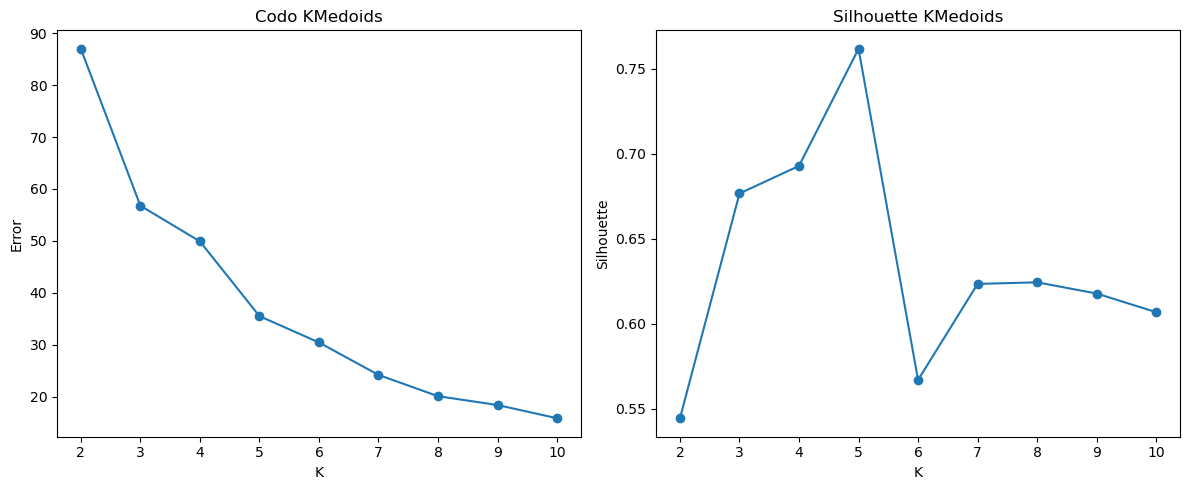

Mejor K KMedoids segun silhouette: 5


,algoritmo,k,errorCodo,silhouette,silhouetteMinCluster,silhouettePromedioClusters
0,KMedoids,2,86.982274,0.544264,0.498845,0.612392
1,KMedoids,3,56.773364,0.676642,0.445508,0.628533
2,KMedoids,4,49.901198,0.692890,0.000000,0.526034
3,KMedoids,5,35.511991,0.761858,0.000000,0.631565
4,KMedoids,6,30.437017,0.566828,0.000000,0.615867
5,KMedoids,7,24.192891,0.623386,0.000000,0.619191
6,KMedoids,8,20.092091,0.624331,0.000000,0.624710
7,KMedoids,9,18.389611,0.617724,0.000000,0.582542
8,KMedoids,10,15.844997,0.606737,0.000000,0.569354


In [ ]:
# evalua el mejor Kmedoids
DfMetricasKMedoids, ModelosKMedoids = evaluarAlgoritmoParticion(XMatriz, RangoK, "KMedoids", semilla=Semilla)
RutaKMedoidsGrafica = os.path.join(RutaGraficas, "metricasKMedoids.png")
graficarMetricasParticion(DfMetricasKMedoids, "KMedoids", RutaKMedoidsGrafica)

print("Mejor K KMedoids segun silhouette:", obtenerMejorKPorSilhouette(DfMetricasKMedoids))
DfMetricasKMedoids

# Seleccion del mejor modelo y asignacion de clusters finales

In [ ]:
# se selecciona el mejor modelo
MejorKKMeans = obtenerMejorKPorSilhouette(DfMetricasKMeans)
MejorKKMedoids = obtenerMejorKPorSilhouette(DfMetricasKMedoids)
EtiquetasKMeans = ModelosKMeans[MejorKKMeans]["etiquetas"]
EtiquetasKMedoids = ModelosKMedoids[MejorKKMedoids]["etiquetas"]
DfDataset["clusterKMeans"] = EtiquetasKMeans
DfDataset["clusterKMedoids"] = EtiquetasKMedoids

SilhouetteKMeans = float(DfMetricasKMeans.loc[DfMetricasKMeans["k"] == MejorKKMeans, "silhouette"].iloc[0])
SilhouetteKMedoids = float(DfMetricasKMedoids.loc[DfMetricasKMedoids["k"] == MejorKKMedoids, "silhouette"].iloc[0])
AlgoritmoFinal = "KMeans" if SilhouetteKMeans >= SilhouetteKMedoids else "KMedoids"
ColumnaClusterFinal = "clusterKMeans" if AlgoritmoFinal == "KMeans" else "clusterKMedoids"
MejorKFinal = MejorKKMeans if AlgoritmoFinal == "KMeans" else MejorKKMedoids
DfDataset["clusterFinal"] = DfDataset[ColumnaClusterFinal]

print("Algoritmo final:", AlgoritmoFinal)
print("Mejor K final:", MejorKFinal)
print("Silhouette final:", SilhouetteKMeans if AlgoritmoFinal == "KMeans" else SilhouetteKMedoids)

DfDataset[["nombreArchivo", "clusterKMeans", "clusterKMedoids", "clusterFinal"]].head(20)

Algoritmo final: KMeans
Mejor K final: 5
Silhouette final: 0.7618575204354998


,nombreArchivo,clusterKMeans,clusterKMedoids,clusterFinal
0,1F2EB7B090018D975E6D9B40868C94CA,1,0,1
1,33DE5067A433A6EC5C328067DC18EC37,1,0,1
2,65018CD542145A3792BA09985734C12A,1,0,1
3,650A6FCA433EE243391E4B4C11F09438,1,0,1
4,6FAA4740F99408D4D2DDDD0B09BBDEFD,1,0,1
5,785003A405BC7A4EBCBB21DDB757BF3F,1,0,1
6,8442AE37B91F279A9F06DE4C60B286A3,1,0,1
7,99A39866A657A10949FCB6D634BB30D5,1,0,1
8,A316D5AECA269CA865077E7FFF356E7D,1,0,1
9,AAAz2E1B6940985A23E5639450F8391820655,2,2,2


# Reduccion de dimensionalidad y visualizacion de clusters en 2D

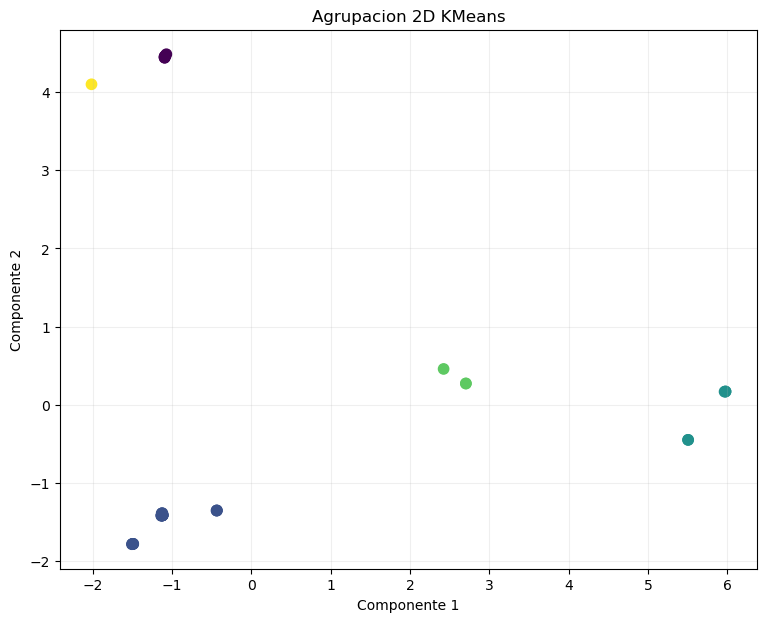

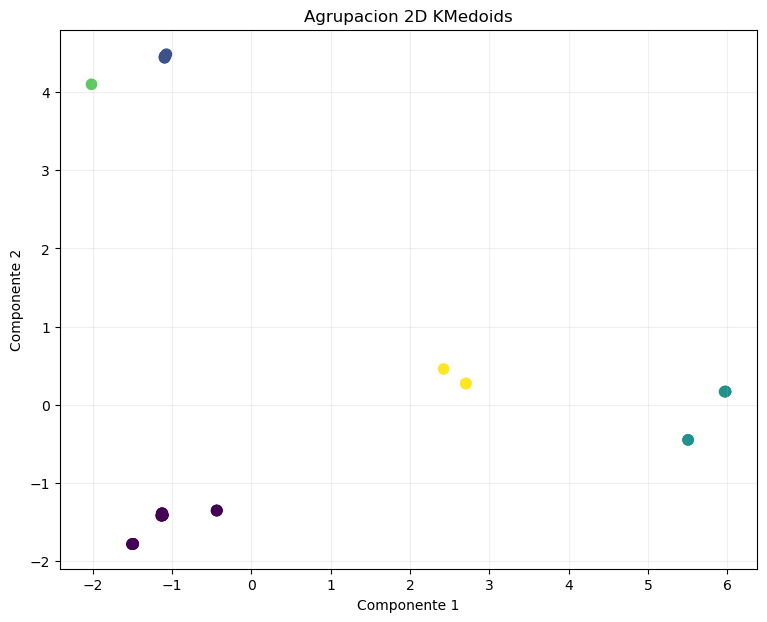

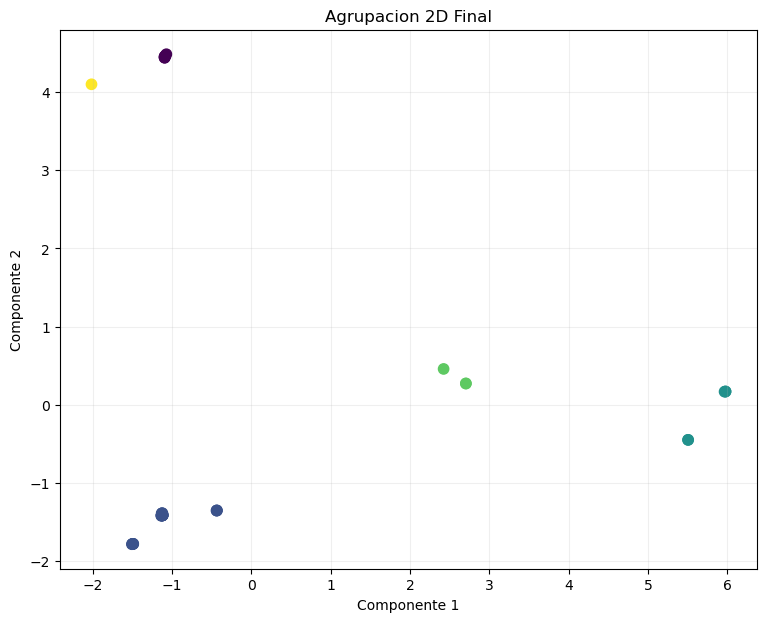

In [ ]:
# se reduce la matriz a 2 dimensiones 
def reducirADosDimensiones(matriz, semilla: int = 42) -> np.ndarray:
    if hasattr(matriz, "toarray"):
        matrizReducida = TruncatedSVD(n_components=min(50, max(2, matriz.shape[1] - 1)), random_state=semilla).fit_transform(matriz)
    else:
        matrizReducida = matriz

    coordenadas = PCA(n_components=2, random_state=semilla).fit_transform(matrizReducida)
    return coordenadas


# grafica puntos 2D coloreados por cluster
def graficarClusters2D(coordenadas2D: np.ndarray, etiquetas: np.ndarray, titulo: str, rutaSalida: str) -> None:
    plt.figure(figsize=(9, 7))
    dispersion = plt.scatter(coordenadas2D[:, 0], coordenadas2D[:, 1], c=etiquetas, s=55)
    plt.title(titulo)
    plt.xlabel("Componente 1")
    plt.ylabel("Componente 2")
    plt.grid(alpha=0.2)
    plt.savefig(rutaSalida, dpi=200, bbox_inches="tight")
    plt.show()


CoordenadasBase2D = reducirADosDimensiones(XMatriz, semilla=Semilla)
RutaClustersKMeans = os.path.join(RutaGraficas, "clusters2D_KMeans.png")
RutaClustersKMedoids = os.path.join(RutaGraficas, "clusters2D_KMedoids.png")
RutaClustersFinal = os.path.join(RutaGraficas, "clusters2D_Final.png")

graficarClusters2D(CoordenadasBase2D, DfDataset["clusterKMeans"].values, "Agrupacion 2D KMeans", RutaClustersKMeans)
graficarClusters2D(CoordenadasBase2D, DfDataset["clusterKMedoids"].values, "Agrupacion 2D KMedoids", RutaClustersKMedoids)
graficarClusters2D(CoordenadasBase2D, DfDataset["clusterFinal"].values, "Agrupacion 2D Final", RutaClustersFinal)

# Funciones para generar embeddings de Gemini y reducirlos a 2D

In [ ]:
# se define la api key de Gemini se cambio por seguridad
%env GEMINI_API_KEY=xxxxx

env: GEMINI_API_KEY=xxxxx


In [ ]:
# aqui se generan los embeddings de Gemini por lotes
def generarEmbeddingsGemini(listaTextos: list[str], apiKey: str, modelo: str = "gemini-embedding-001", tamanoLote: int = 25, dimensionSalida: int = 256) -> np.ndarray:
    cliente = genai.Client(api_key=apiKey)
    listaEmbeddings = []

    for inicio in range(0, len(listaTextos), tamanoLote):
        fin = inicio + tamanoLote
        lote = listaTextos[inicio:fin]

        respuesta = cliente.models.embed_content(
            model=modelo,
            contents=lote,
            config=types.EmbedContentConfig(
                task_type="CLUSTERING",
                output_dimensionality=dimensionSalida,
            ),
        )

        for embedding in respuesta.embeddings:
            vector = np.array(embedding.values, dtype=np.float32)
            listaEmbeddings.append(vector)

        print(f"Lote procesado: {min(fin, len(listaTextos))}/{len(listaTextos)}")
        time.sleep(1)

    return np.vstack(listaEmbeddings)


# Reduce embeddings a 2D para visualizarlos
def reducirEmbeddingsA2D(matrizEmbeddings: np.ndarray, semilla: int = 42) -> np.ndarray:
    if len(matrizEmbeddings.shape) != 2:
        raise ValueError("La matriz de embeddings debe tener 2 dimensiones")
    numeroMuestras, numeroFeatures = matrizEmbeddings.shape
    if numeroMuestras < 2:
        raise ValueError("Se necesitan al menos 2 muestras para reducir a 2 dimensiones")
    if numeroFeatures < 2:
        raise ValueError("Se necesitan al menos 2 features para reducir a 2 dimensiones")
    maximoComponentesPermitidos = min(numeroMuestras - 1, numeroFeatures)
    if maximoComponentesPermitidos < 2:
        raise ValueError("No hay suficientes dimensiones para aplicar PCA a 2 componentes")
    if numeroFeatures > 50:
        componentesIntermedios = min(50, maximoComponentesPermitidos)
        if componentesIntermedios >= 2:
            matrizBase = PCA(
                n_components=componentesIntermedios,
                random_state=semilla
            ).fit_transform(matrizEmbeddings)
        else:
            matrizBase = matrizEmbeddings
    else:
        matrizBase = matrizEmbeddings
    numeroMuestrasBase, numeroFeaturesBase = matrizBase.shape
    componentesFinales = min(2, numeroMuestrasBase, numeroFeaturesBase)
    if componentesFinales < 2:
        raise ValueError("No fue posible reducir los embeddings a 2 dimensiones")
    coordenadas = PCA(
        n_components=2,
        random_state=semilla
    ).fit_transform(matrizBase)

    return coordenadas

# Generacion de embeddings de Gemini 

Checkpoint encontrado. Se reanuda desde 40/40
Estado detectado. Ultimo indice procesado: 40/40


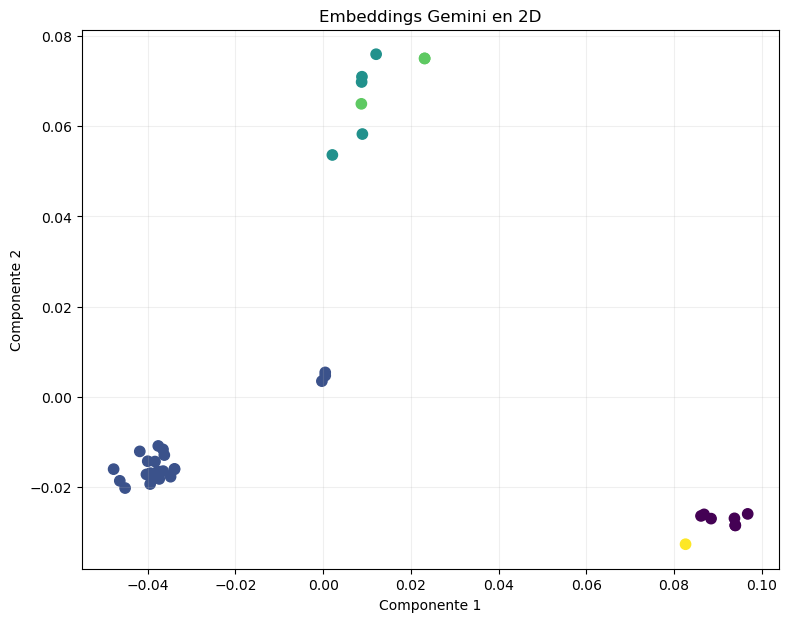

Embeddings guardados en: ./salidasLab3/tablas/embeddingsGemini.npy
Checkpoint guardado en: ./salidasLab3/tablas/embeddingsGemini_checkpoint.npy
Estado guardado en: ./salidasLab3/tablas/embeddingsGemini_estado.json


In [ ]:
# se llama la api keey y se generan los embeddings y se guardan para prevenir limites de Gemini
# con ayuda de gpt para establecerlo funcional
ApiKeyGemini = os.getenv("GEMINI_API_KEY", "").strip()

RutaEmbeddingsNpy = os.path.join(RutaTablas, "embeddingsGemini.npy")
RutaEmbeddingsCheckpointNpy = os.path.join(RutaTablas, "embeddingsGemini_checkpoint.npy")
RutaEmbeddingsEstadoJson = os.path.join(RutaTablas, "embeddingsGemini_estado.json")
RutaGemini2D = os.path.join(RutaGraficas, "embeddingsGemini2D.png")

# se definen los tamanio
TamanoLoteGemini = 5
DimensionSalidaGemini = 256
EsperaEntreLotesSegundos = 5
EsperaPorQuotaSegundos = 130
MaxReintentosPorLote = 100

if not ApiKeyGemini:
    print("No se encontro GEMINI_API_KEY")
    print("Antes de correr esta celda exporta tu llave")
    print("Ejemplo en notebook:")
    print('%env GEMINI_API_KEY=TU_API_KEY')
else:
    ListaDocumentosGemini = DfDataset["documentoCompleto"].fillna("").astype(str).tolist()
    TotalDocumentos = len(ListaDocumentosGemini)
    cliente = genai.Client(api_key=ApiKeyGemini)
    EmbeddingsAcumulados = []
    IndiceInicio = 0

    if os.path.exists(RutaEmbeddingsCheckpointNpy):
        try:
            EmbeddingsAcumulados = np.load(RutaEmbeddingsCheckpointNpy).tolist()
            IndiceInicio = len(EmbeddingsAcumulados)
            print(f"Checkpoint encontrado. Se reanuda desde {IndiceInicio}/{TotalDocumentos}")
        except Exception:
            EmbeddingsAcumulados = []
            IndiceInicio = 0
            print("No se pudo leer el checkpoint anterior. Se reinicia el proceso")

    if os.path.exists(RutaEmbeddingsEstadoJson):
        try:
            with open(RutaEmbeddingsEstadoJson, "r", encoding="utf-8") as archivoEstado:
                EstadoGuardado = json.load(archivoEstado)
            IndiceEstado = int(EstadoGuardado.get("indiceProcesado", IndiceInicio))
            if IndiceEstado > IndiceInicio:
                IndiceInicio = IndiceEstado
            print(f"Estado detectado. Ultimo indice procesado: {IndiceInicio}/{TotalDocumentos}")
        except Exception:
            print("No se pudo leer el estado json. Se usa el checkpoint disponible")

    while IndiceInicio < TotalDocumentos:
        IndiceFin = min(IndiceInicio + TamanoLoteGemini, TotalDocumentos)
        LoteActual = ListaDocumentosGemini[IndiceInicio:IndiceFin]
        Reintentos = 0
        LoteProcesado = False

        while not LoteProcesado and Reintentos < MaxReintentosPorLote:
            try:
                respuesta = cliente.models.embed_content(
                    model=ModeloGeminiEmbeddings,
                    contents=LoteActual,
                    config=types.EmbedContentConfig(
                        task_type="CLUSTERING",
                        output_dimensionality=DimensionSalidaGemini,
                    ),
                )

                for embedding in respuesta.embeddings:
                    vector = np.array(embedding.values, dtype=np.float32)
                    EmbeddingsAcumulados.append(vector)

                MatrizParcial = np.vstack(EmbeddingsAcumulados)
                np.save(RutaEmbeddingsCheckpointNpy, MatrizParcial)
                with open(RutaEmbeddingsEstadoJson, "w", encoding="utf-8") as archivoEstado:
                    json.dump(
                        {
                            "indiceProcesado": len(EmbeddingsAcumulados),
                            "totalDocumentos": TotalDocumentos,
                            "tamanoLote": TamanoLoteGemini,
                            "dimensionSalida": DimensionSalidaGemini,
                        },
                        archivoEstado,
                        ensure_ascii=False,
                        indent=2,
                    )

                IndiceInicio = len(EmbeddingsAcumulados)
                LoteProcesado = True
                print(f"Lote procesado: {IndiceInicio}/{TotalDocumentos}")

                if IndiceInicio < TotalDocumentos:
                    time.sleep(EsperaEntreLotesSegundos)

            except Exception as error:
                MensajeError = str(error)
                Reintentos += 1
                if "429" in MensajeError or "RESOURCE_EXHAUSTED" in MensajeError:
                    print(f"Quota alcanzada en lote {IndiceInicio}:{IndiceFin}. Reintento {Reintentos}/{MaxReintentosPorLote}")
                    print(f"Esperando {EsperaPorQuotaSegundos} segundos para continuar sin perder progreso")
                    time.sleep(EsperaPorQuotaSegundos)
                else:
                    print(f"Error inesperado en lote {IndiceInicio}:{IndiceFin}")
                    print(MensajeError)
                    raise

        if not LoteProcesado:
            raise RuntimeError("No se pudo procesar un lote despues de multiples reintentos")

    MatrizEmbeddingsGemini = np.vstack(EmbeddingsAcumulados).astype(np.float32)
    np.save(RutaEmbeddingsNpy, MatrizEmbeddingsGemini)
    CoordenadasGemini2D = reducirEmbeddingsA2D(MatrizEmbeddingsGemini, semilla=Semilla)

    plt.figure(figsize=(9, 7))
    plt.scatter(CoordenadasGemini2D[:, 0], CoordenadasGemini2D[:, 1], c=DfDataset["clusterFinal"].values, s=55)
    plt.title("Embeddings Gemini en 2D")
    plt.xlabel("Componente 1")
    plt.ylabel("Componente 2")
    plt.grid(alpha=0.2)
    plt.savefig(RutaGemini2D, dpi=200, bbox_inches="tight")
    plt.show()

    print("Embeddings guardados en:", RutaEmbeddingsNpy)
    print("Checkpoint guardado en:", RutaEmbeddingsCheckpointNpy)
    print("Estado guardado en:", RutaEmbeddingsEstadoJson)

# Funciones para calcular similitud de Jaccard entre muestras

In [ ]:
# se contruyen mapas archivo a conjunto de strings y funciones
def construirMapasFeatures(dataframe: pd.DataFrame) -> tuple[dict[str, set[str]], dict[str, set[str]]]:
    mapaStrings = {}
    mapaFunciones = {}

    for _, fila in dataframe.iterrows():
        rutaArchivo = fila["rutaArchivo"]
        stringsLista = str(fila["stringsTexto"]).split() if pd.notna(fila["stringsTexto"]) else []
        funcionesLista = str(fila["funcionesTexto"]).split() if pd.notna(fila["funcionesTexto"]) else []
        mapaStrings[rutaArchivo] = listaAConjunto(stringsLista)
        mapaFunciones[rutaArchivo] = listaAConjunto(funcionesLista)

    return mapaStrings, mapaFunciones


# se calcula similitud por pares para todos los archivos
def calcularSimilitudesPares(mapaFeatures: dict[str, set[str]]) -> pd.DataFrame:
    archivos = sorted(mapaFeatures.keys())
    filas = []
    for archivoA, archivoB in combinations(archivos, 2):
        similitud = jaccardConjuntos(mapaFeatures[archivoA], mapaFeatures[archivoB])
        filas.append({
            "archivoA": archivoA,
            "archivoB": archivoB,
            "similitud": float(similitud),
        })
    return pd.DataFrame(filas)


# Resumelel resumene cuantas conexiones existen por umbral
def resumirPorUmbrales(dataframeSimilitud: pd.DataFrame, listaUmbrales: list[float]) -> pd.DataFrame:
    filas = []
    if dataframeSimilitud.empty:
        return pd.DataFrame()
    promedio = float(dataframeSimilitud["similitud"].mean())
    mediana = float(dataframeSimilitud["similitud"].median())
    paresTotales = int(len(dataframeSimilitud))
    for umbral in listaUmbrales:
        conectados = int((dataframeSimilitud["similitud"] >= umbral).sum())
        porcentaje = float((conectados / paresTotales) * 100.0) if paresTotales > 0 else 0.0

        filas.append({
            "umbral": float(umbral),
            "paresTotales": paresTotales,
            "paresConectados": conectados,
            "porcentajeConectado": porcentaje,
            "promedioSimilitud": promedio,
            "medianaSimilitud": mediana,
        })

    return pd.DataFrame(filas)

# Calculo y resumen de similitud para strings y funciones

In [ ]:
MapaStrings, MapaFunciones = construirMapasFeatures(DfDataset)
DfSimStrings = calcularSimilitudesPares(MapaStrings)
DfSimFunciones = calcularSimilitudesPares(MapaFunciones)
DfResumenStrings = resumirPorUmbrales(DfSimStrings, ListaUmbrales)
DfResumenFunciones = resumirPorUmbrales(DfSimFunciones, ListaUmbrales)
RutaSimStrings = os.path.join(RutaTablas, "similitudStrings.csv")
RutaSimFunciones = os.path.join(RutaTablas, "similitudFunciones.csv")
RutaResumenStrings = os.path.join(RutaTablas, "resumenUmbralesStrings.csv")
RutaResumenFunciones = os.path.join(RutaTablas, "resumenUmbralesFunciones.csv")

DfSimStrings.to_csv(RutaSimStrings, index=False, encoding="utf-8")
DfSimFunciones.to_csv(RutaSimFunciones, index=False, encoding="utf-8")
DfResumenStrings.to_csv(RutaResumenStrings, index=False, encoding="utf-8")
DfResumenFunciones.to_csv(RutaResumenFunciones, index=False, encoding="utf-8")

print("Resumen strings")
display(DfResumenStrings)

print("Resumen funciones")
display(DfResumenFunciones)

Resumen strings


,umbral,paresTotales,paresConectados,porcentajeConectado,promedioSimilitud,medianaSimilitud
0,0.60,780,110,14.102564,0.182415,0.053073
1,0.80,780,26,3.333333,0.182415,0.053073
2,0.95,780,9,1.153846,0.182415,0.053073


Resumen funciones


,umbral,paresTotales,paresConectados,porcentajeConectado,promedioSimilitud,medianaSimilitud
0,0.60,780,256,32.820513,0.380391,0.25
1,0.80,780,149,19.102564,0.380391,0.25
2,0.95,780,149,19.102564,0.380391,0.25


# Funciones para generar grafos de similitud

In [ ]:
# se dibujan un grafo de similitud y lo guarda como png
def generarGrafoSimilitud(dataframeCluster: pd.DataFrame, mapaFeatures: dict[str, set[str]], umbral: float, titulo: str, rutaSalida: str) -> None:
    grafo = nx.Graph()
    archivos = dataframeCluster["rutaArchivo"].tolist()
    nombres = dict(zip(dataframeCluster["rutaArchivo"], dataframeCluster["nombreArchivo"]))
    for rutaArchivo in archivos:
        grafo.add_node(rutaArchivo, label=nombres[rutaArchivo])
    for archivoA, archivoB in combinations(archivos, 2):
        similitud = jaccardConjuntos(mapaFeatures.get(archivoA, set()), mapaFeatures.get(archivoB, set()))
        if similitud >= umbral:
            grafo.add_edge(archivoA, archivoB, weight=similitud)
    plt.figure(figsize=(12, 9))
    posiciones = nx.spring_layout(grafo, seed=Semilla, k=0.8)
    nx.draw_networkx_nodes(grafo, posiciones, node_size=900)
    nx.draw_networkx_labels(
        grafo,
        posiciones,
        labels={nodo: grafo.nodes[nodo]["label"][:18] for nodo in grafo.nodes()},
        font_size=8,
    )

    if grafo.number_of_edges() > 0:
        pesos = [grafo[u][v]["weight"] * 3 for u, v in grafo.edges()]
        nx.draw_networkx_edges(grafo, posiciones, width=pesos, alpha=0.7)
    plt.title(titulo)
    plt.axis("off")
    plt.savefig(rutaSalida, dpi=220, bbox_inches="tight")
    plt.show()


# se generan grafos y por familia para cada umbral y tipo de feature
def generarTodosLosGrafos(dataframe: pd.DataFrame, mapaFeatures: dict[str, set[str]], nombreFeature: str, listaUmbrales: list[float], carpetaSalida: str) -> None:
    for umbral in listaUmbrales:
        rutaCompleta = os.path.join(carpetaSalida, f"grafoCompleto_{nombreFeature}_u{str(umbral).replace('.', '')}.png")
        generarGrafoSimilitud(
            dataframeCluster=dataframe,
            mapaFeatures=mapaFeatures,
            umbral=umbral,
            titulo=f"Grafo completo {nombreFeature} umbral {umbral}",
            rutaSalida=rutaCompleta,
        )

        for clusterId in sorted(dataframe["clusterFinal"].unique()):
            dataframeCluster = dataframe[dataframe["clusterFinal"] == clusterId].copy()
            rutaFamilia = os.path.join(carpetaSalida, f"grafoFamilia_{nombreFeature}_cluster{clusterId}_u{str(umbral).replace('.', '')}.png")
            generarGrafoSimilitud(
                dataframeCluster=dataframeCluster,
                mapaFeatures=mapaFeatures,
                umbral=umbral,
                titulo=f"Familia {clusterId} {nombreFeature} umbral {umbral}",
                rutaSalida=rutaFamilia,
            )

# Generacion de grafos completos y por familia

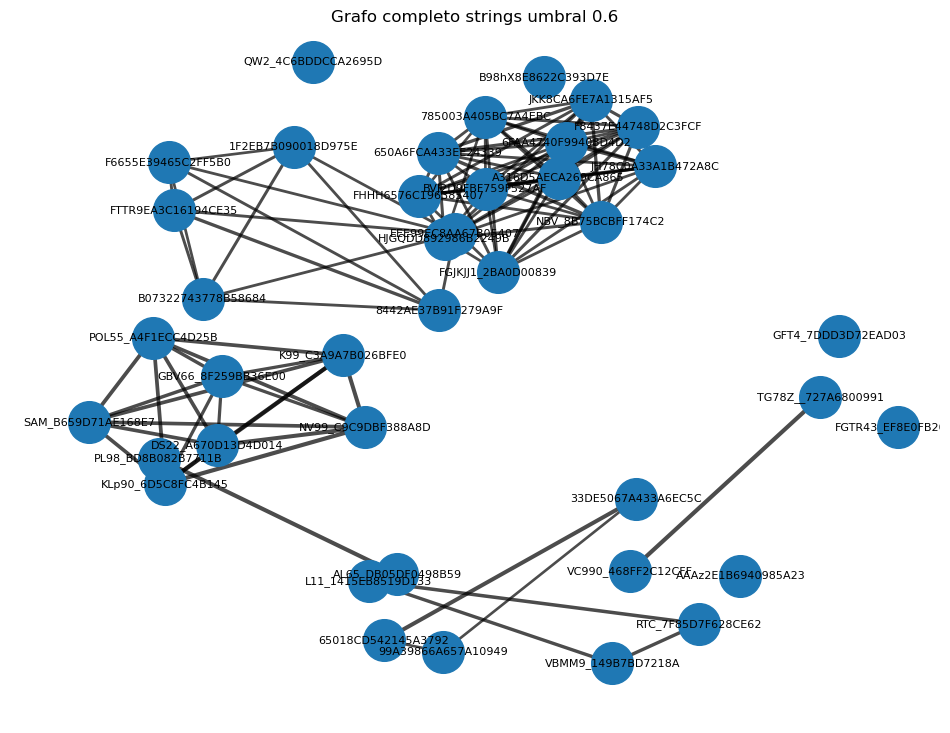

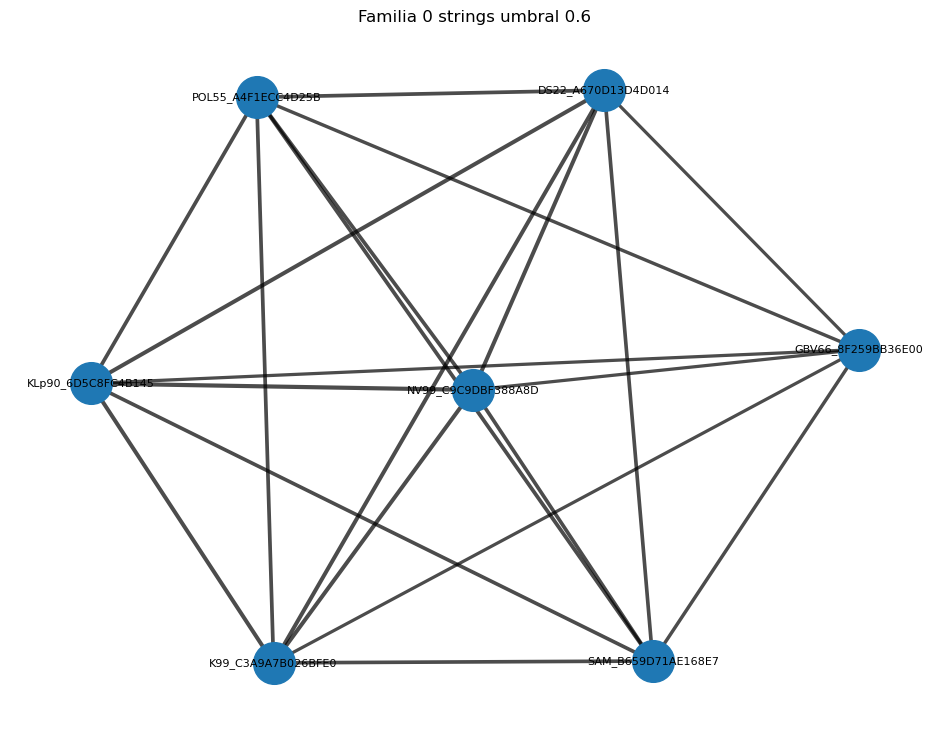

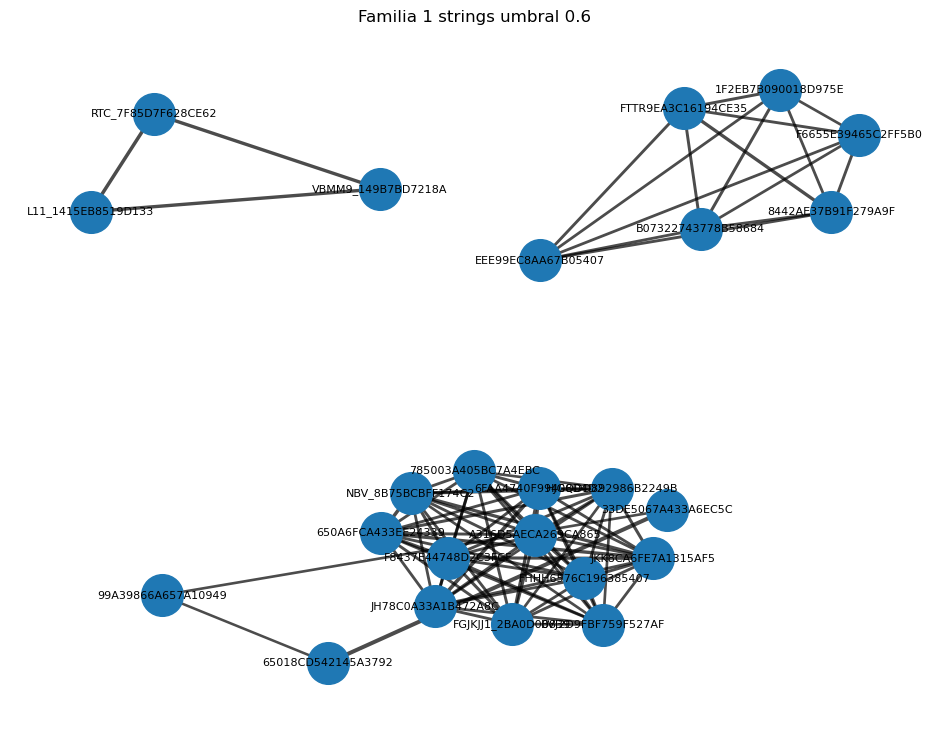

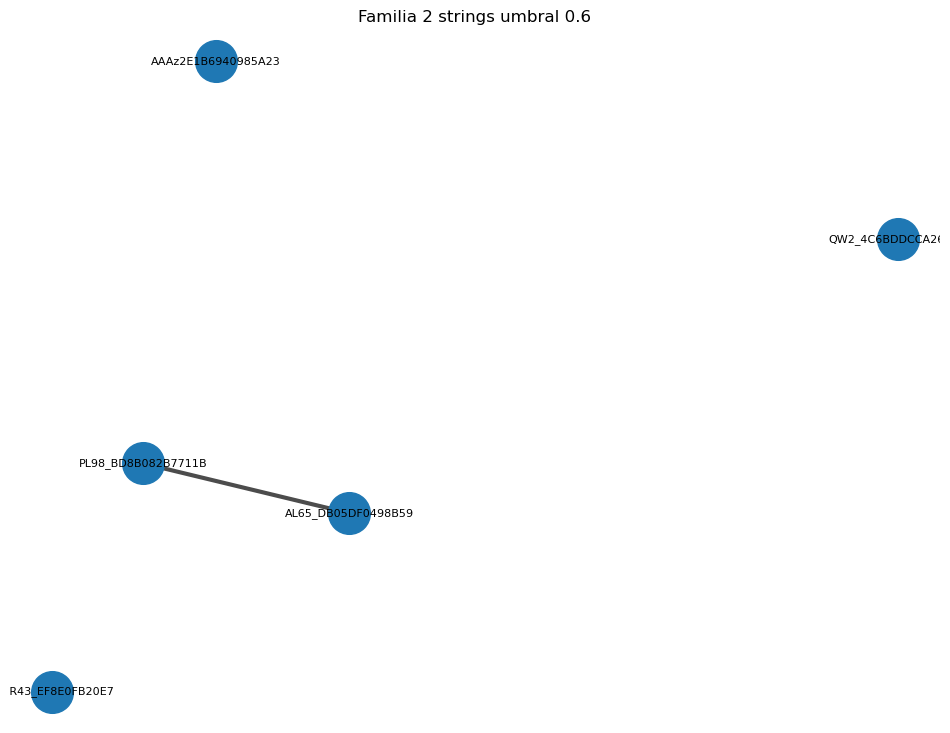

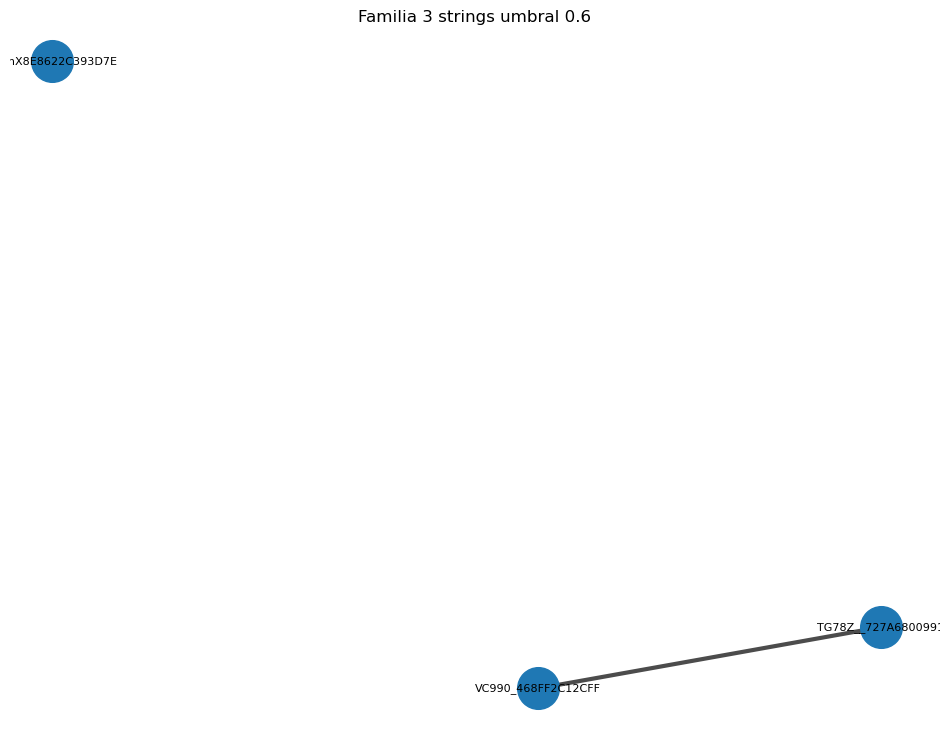

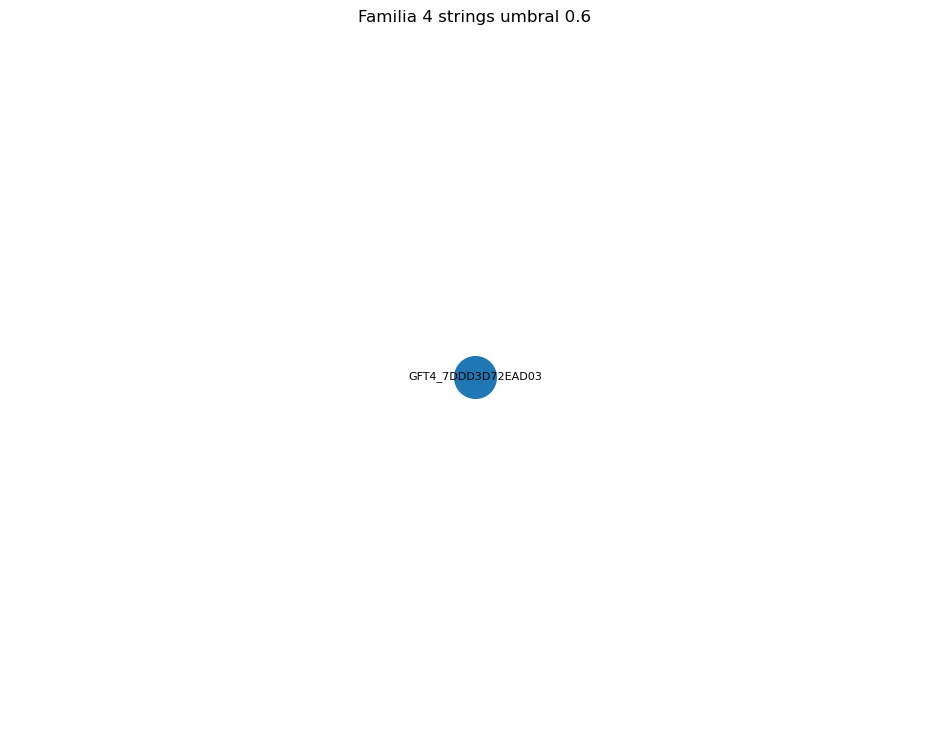

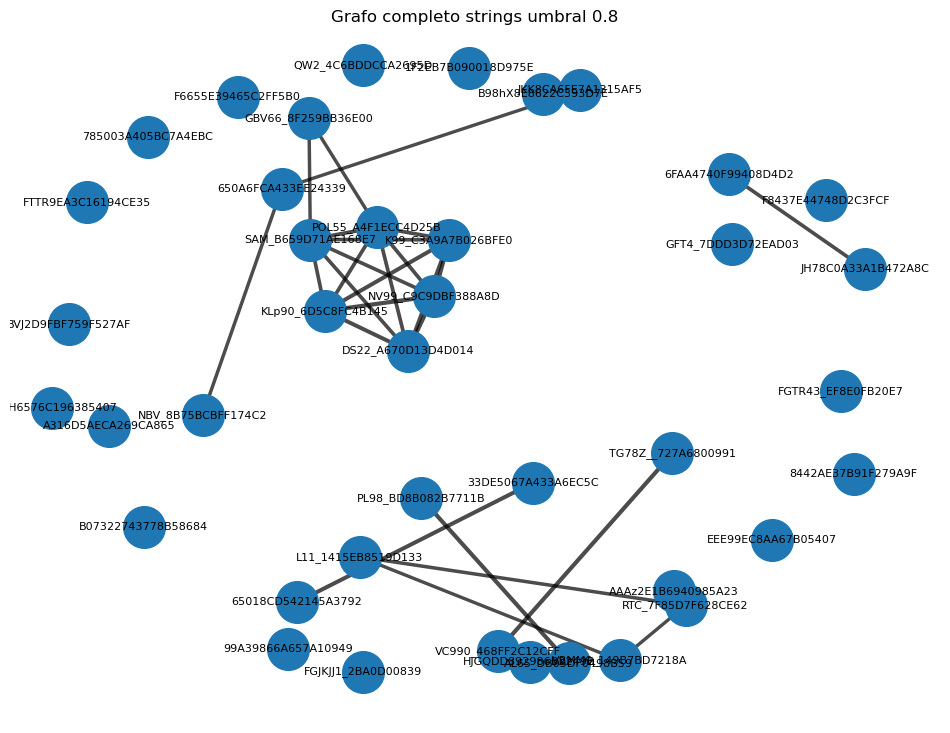

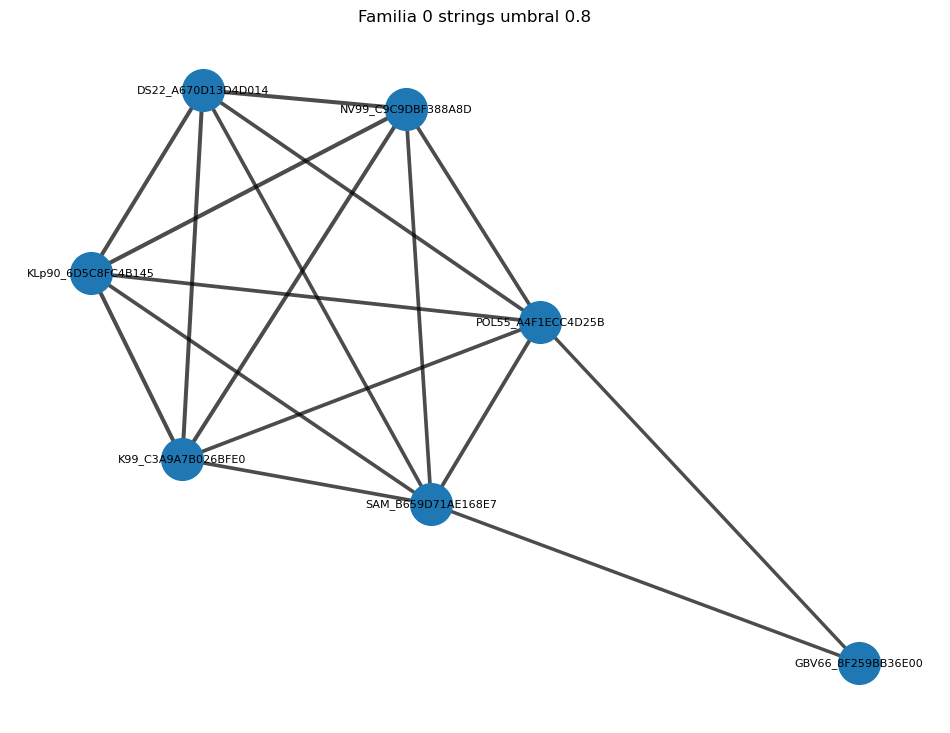

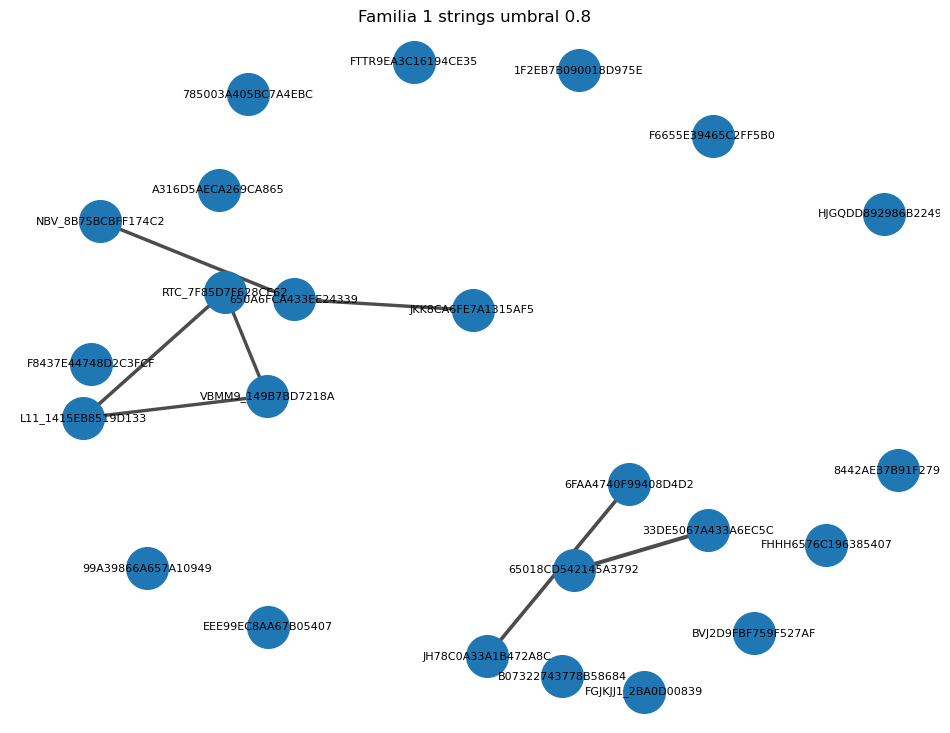

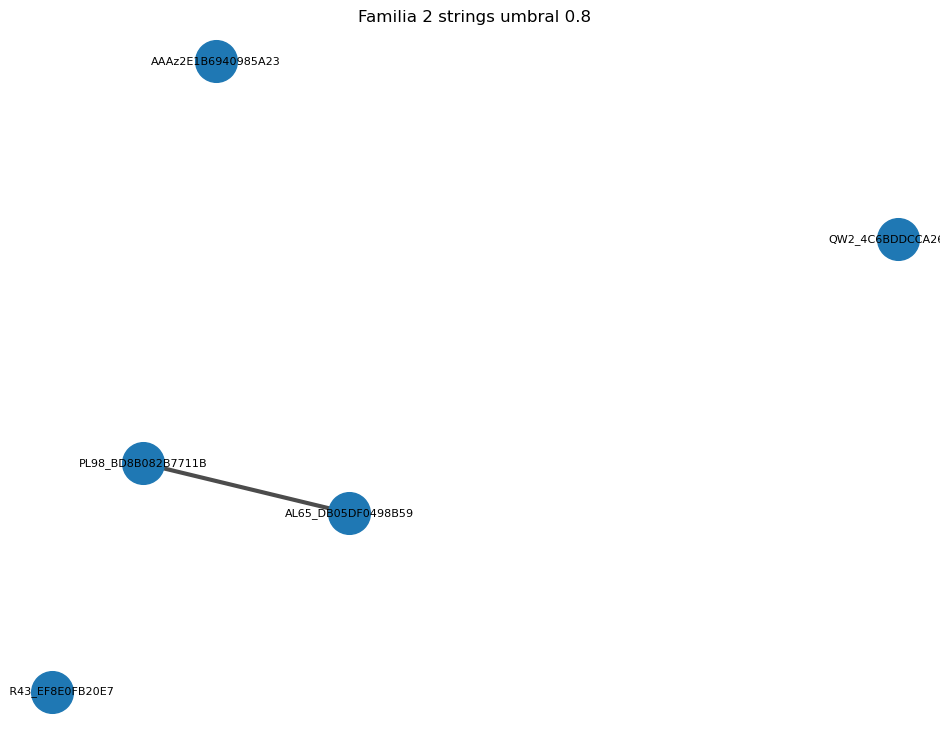

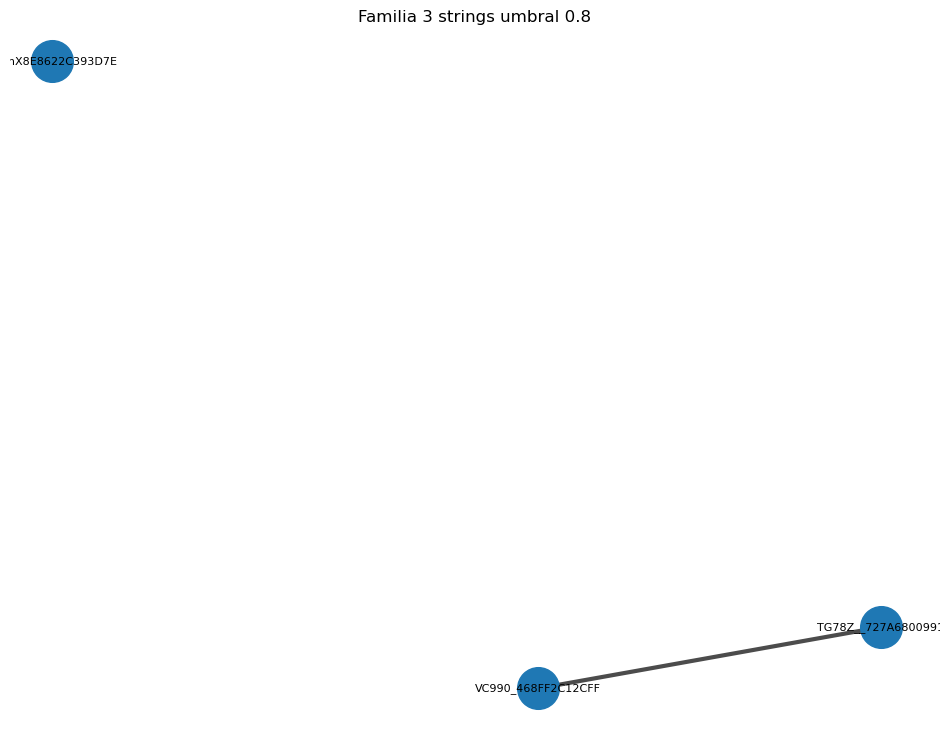

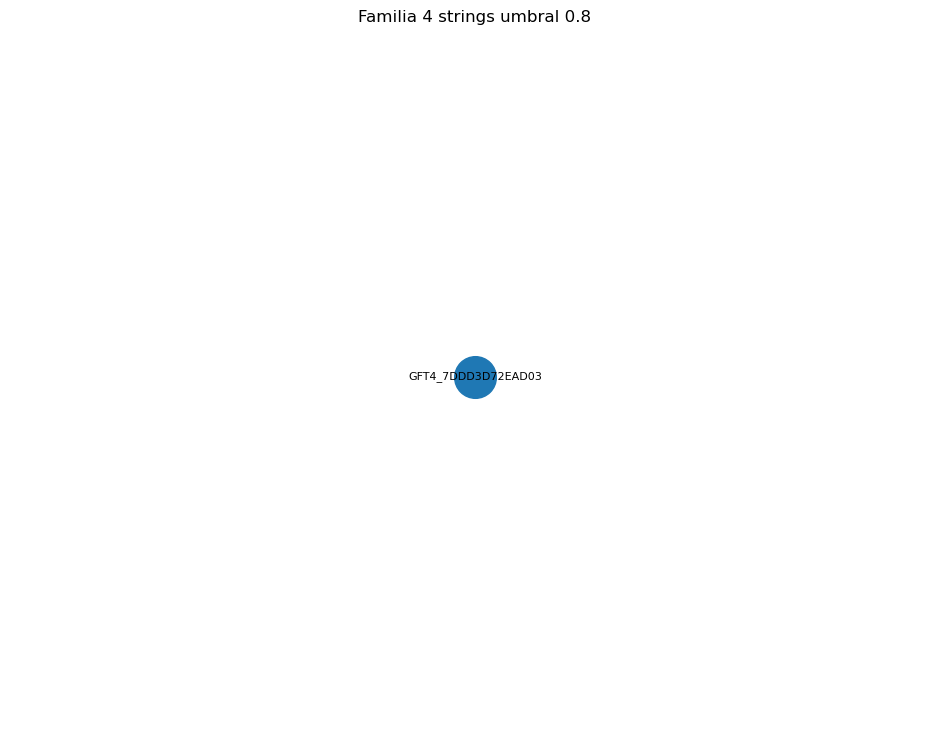

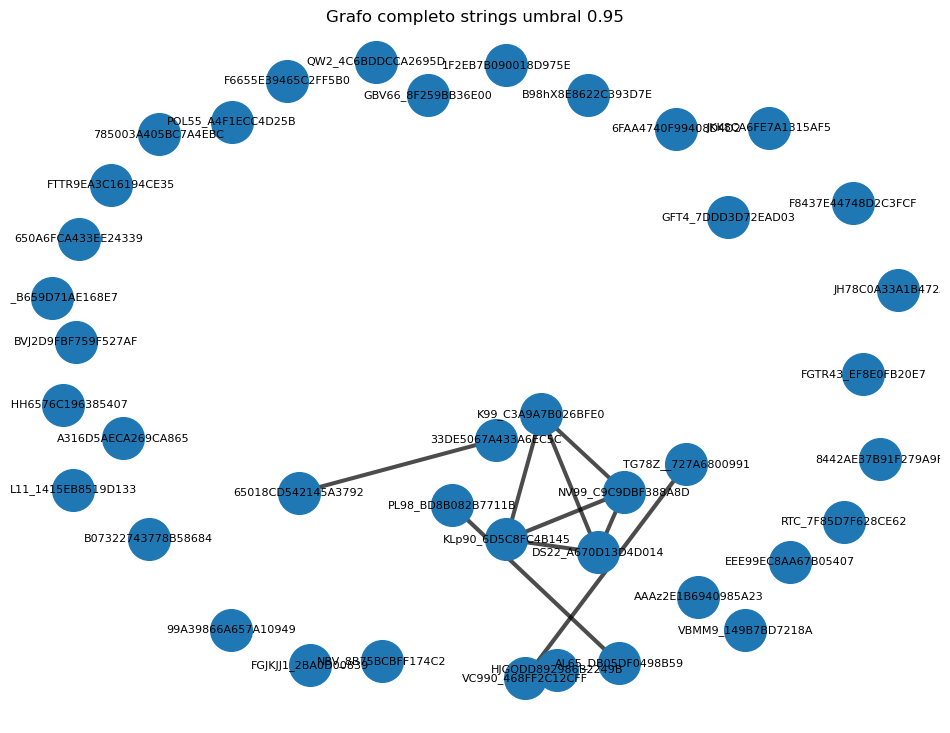

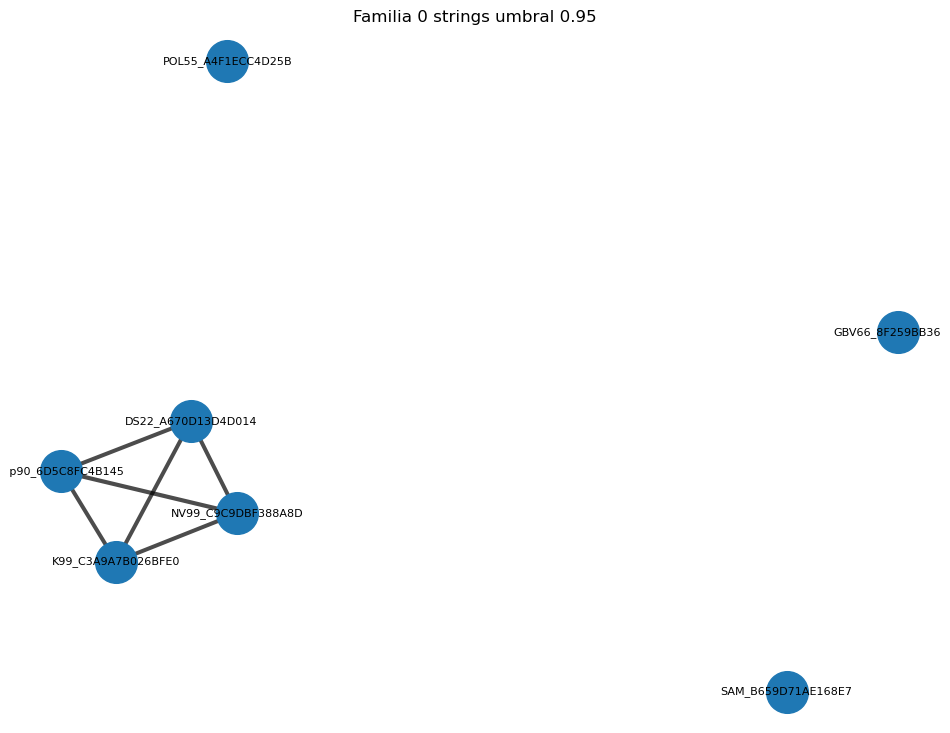

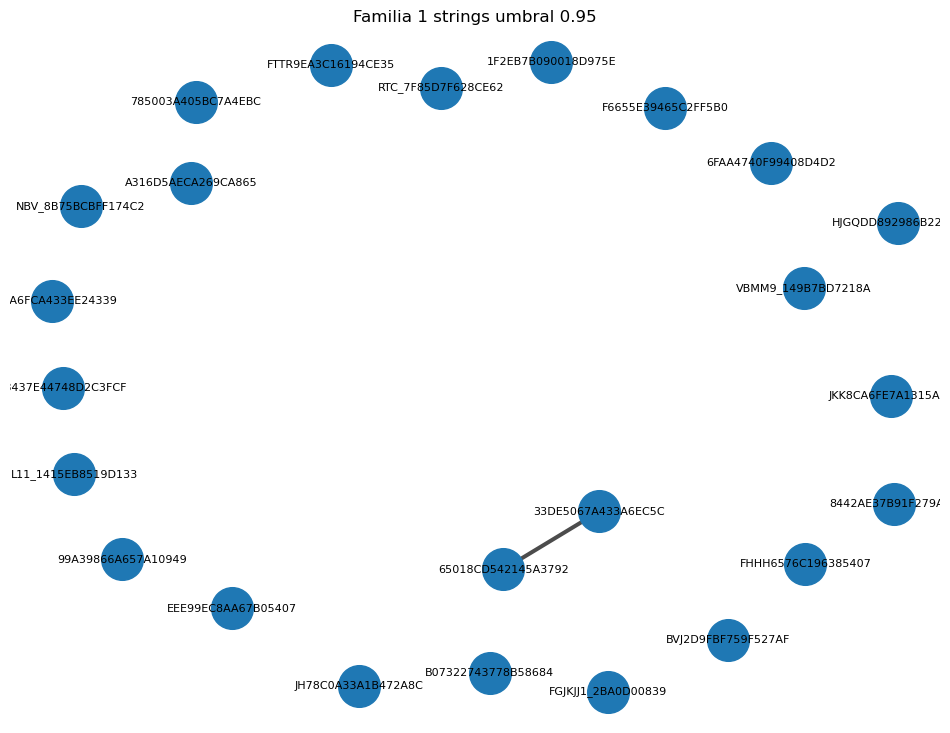

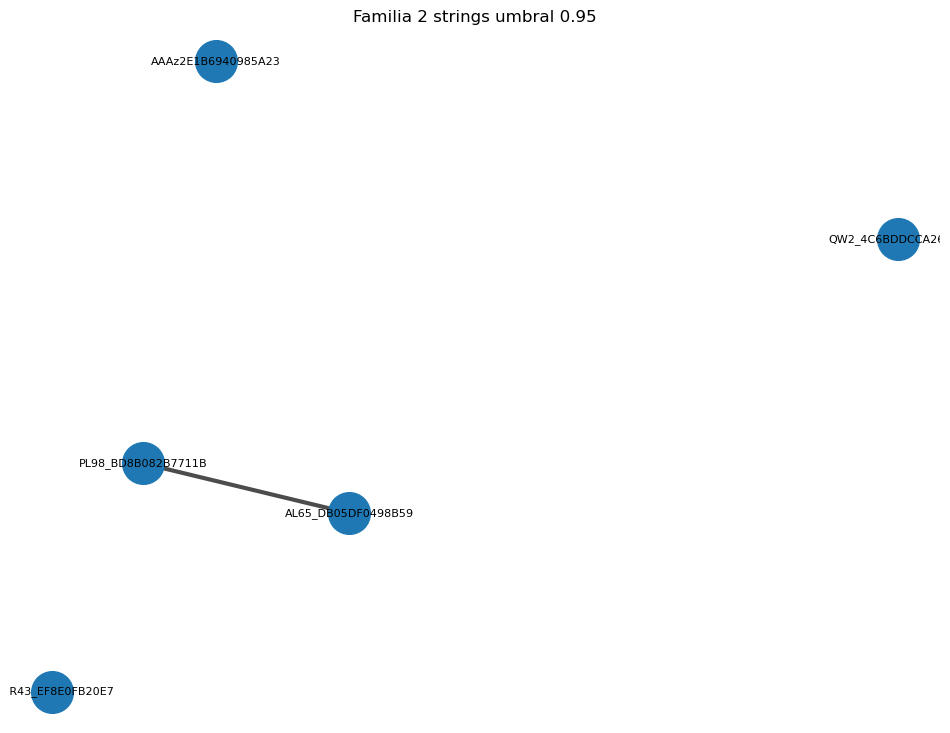

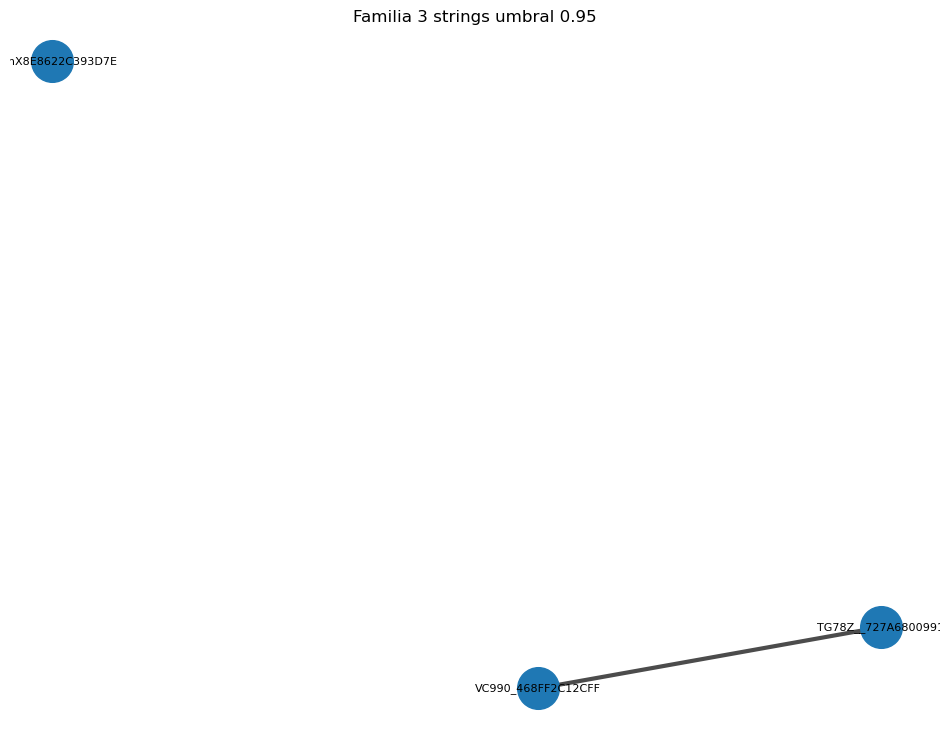

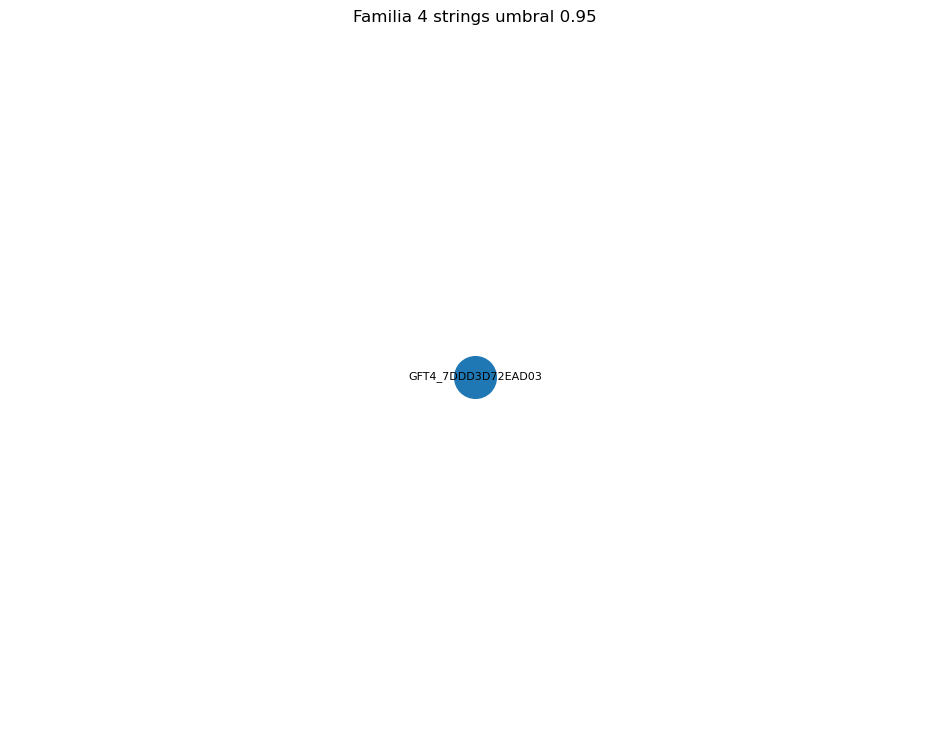

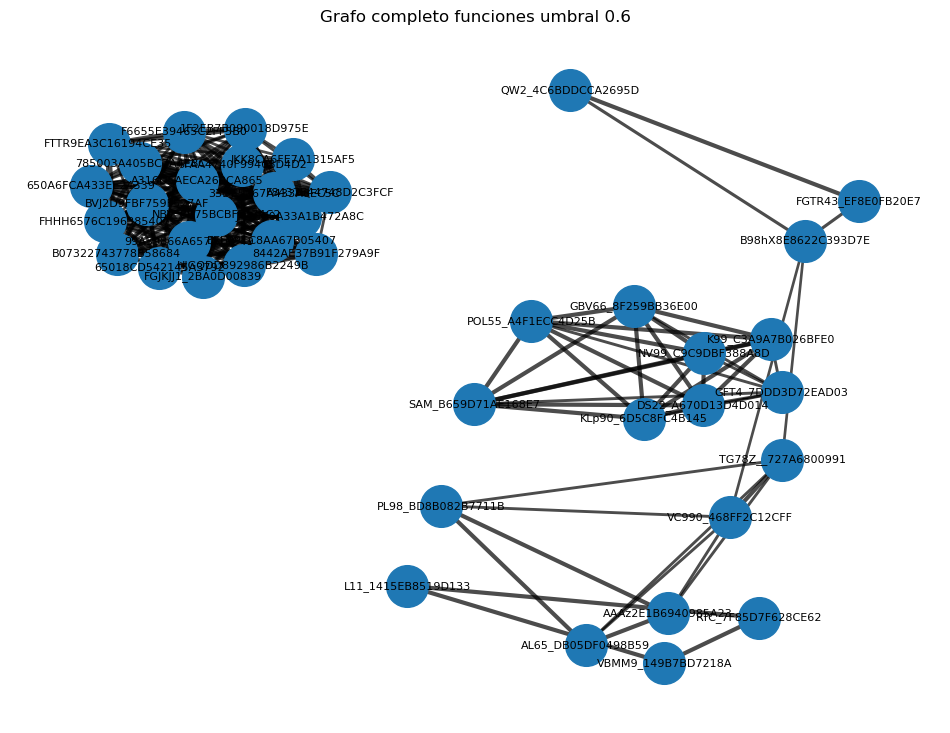

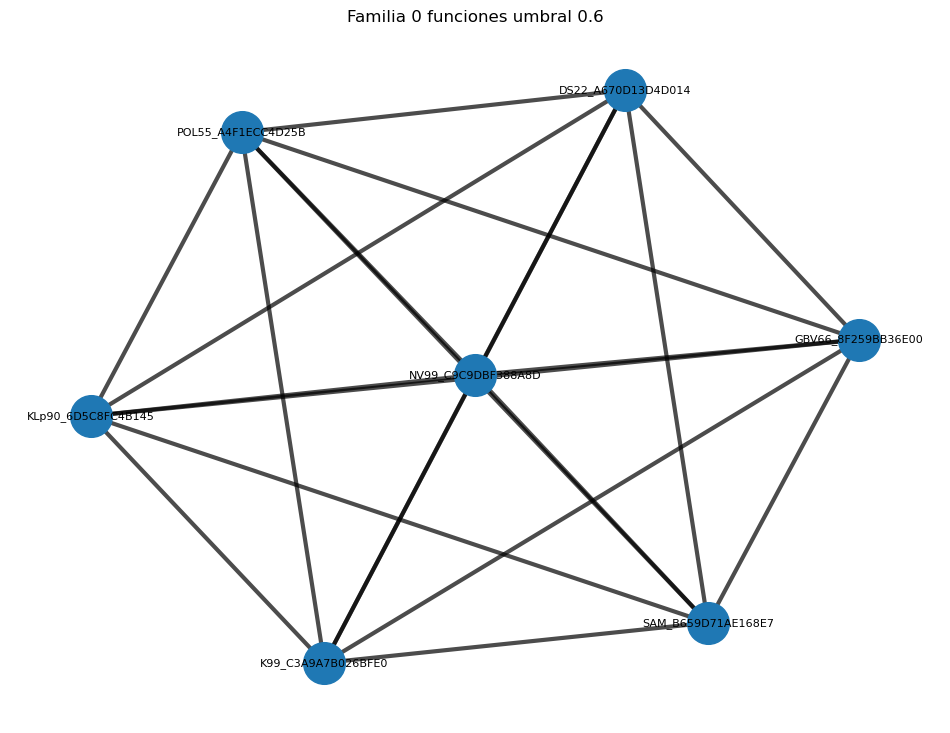

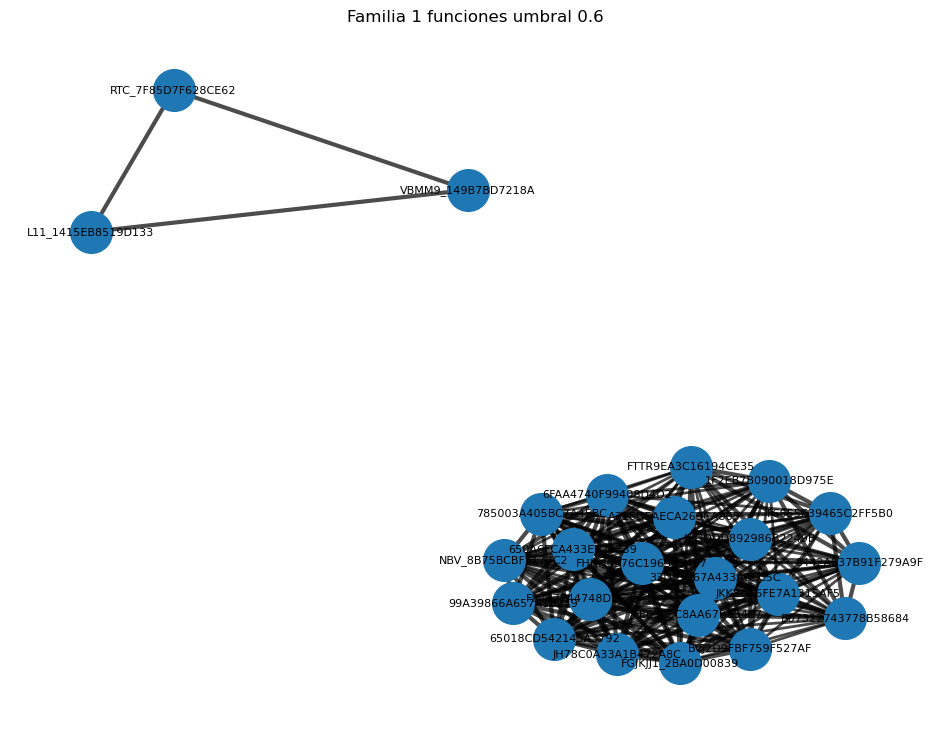

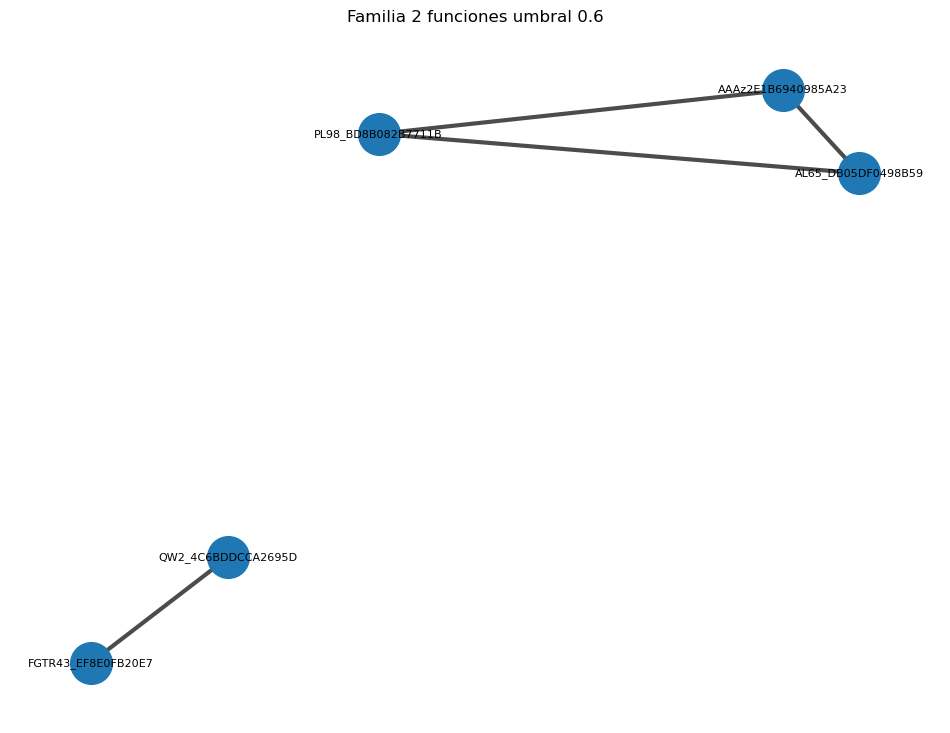

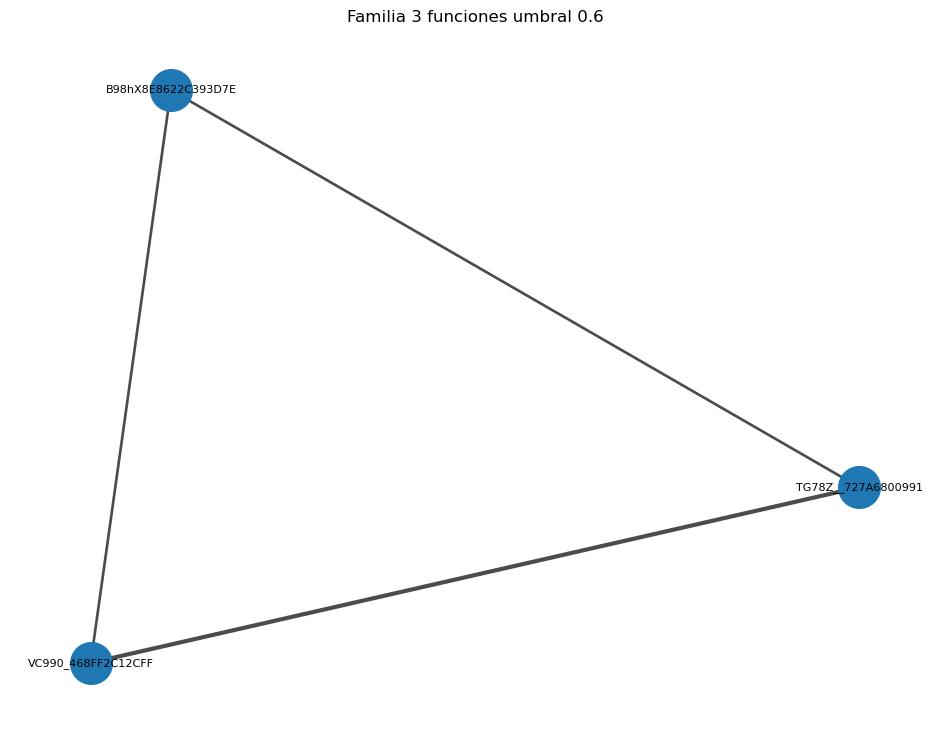

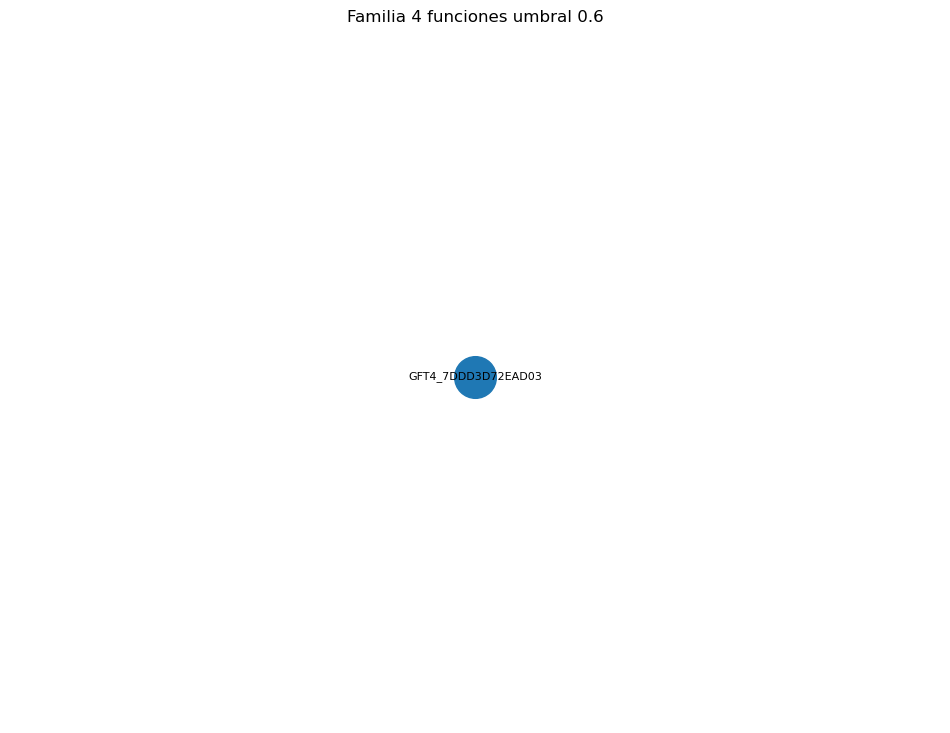

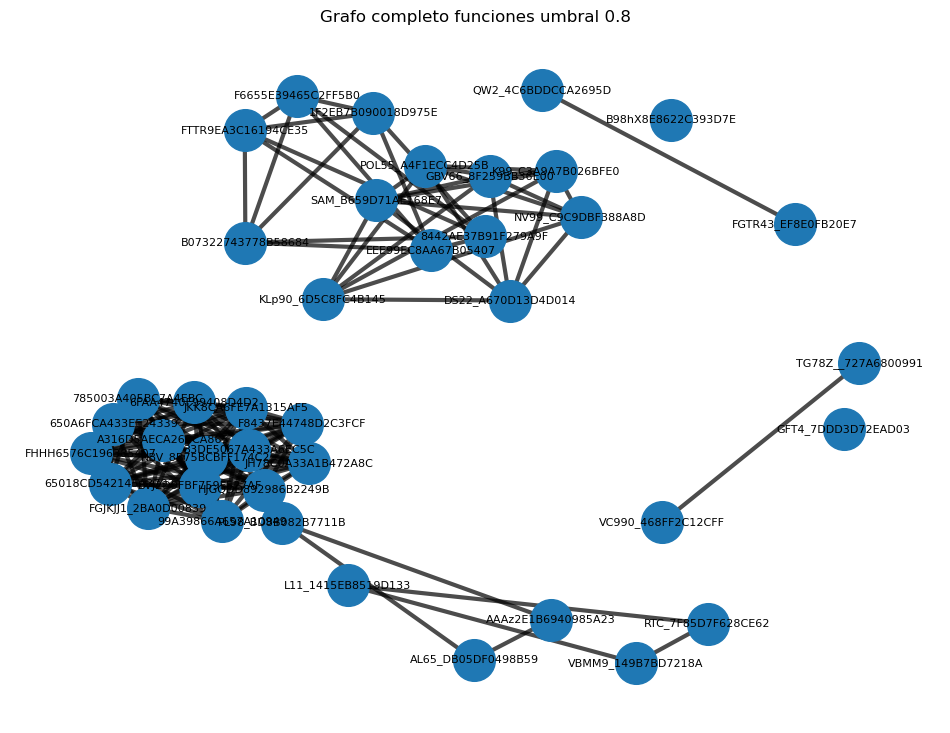

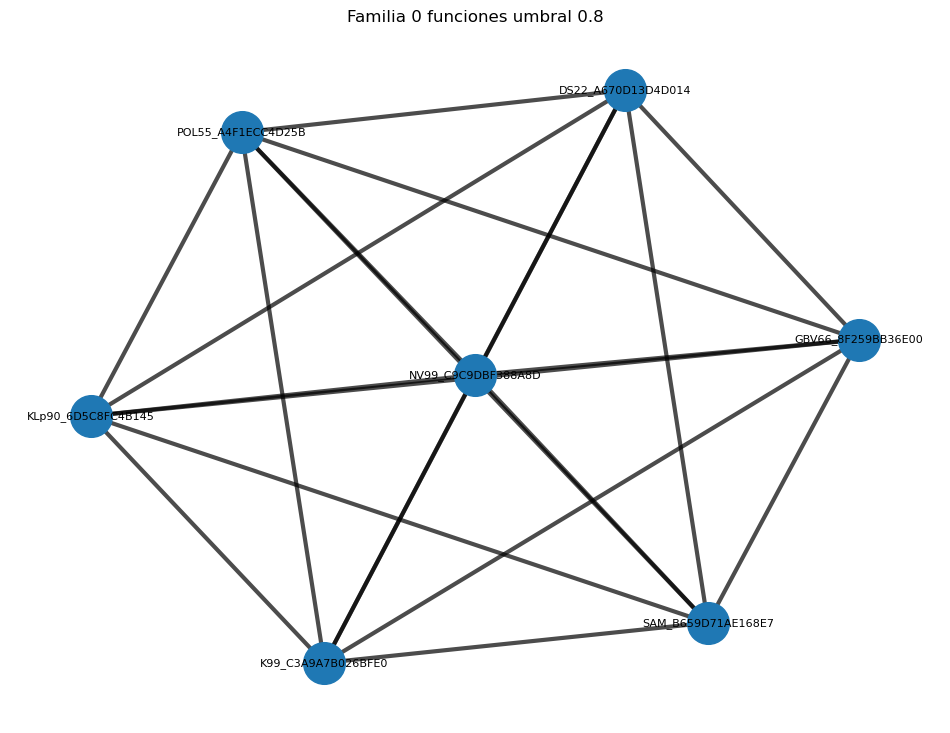

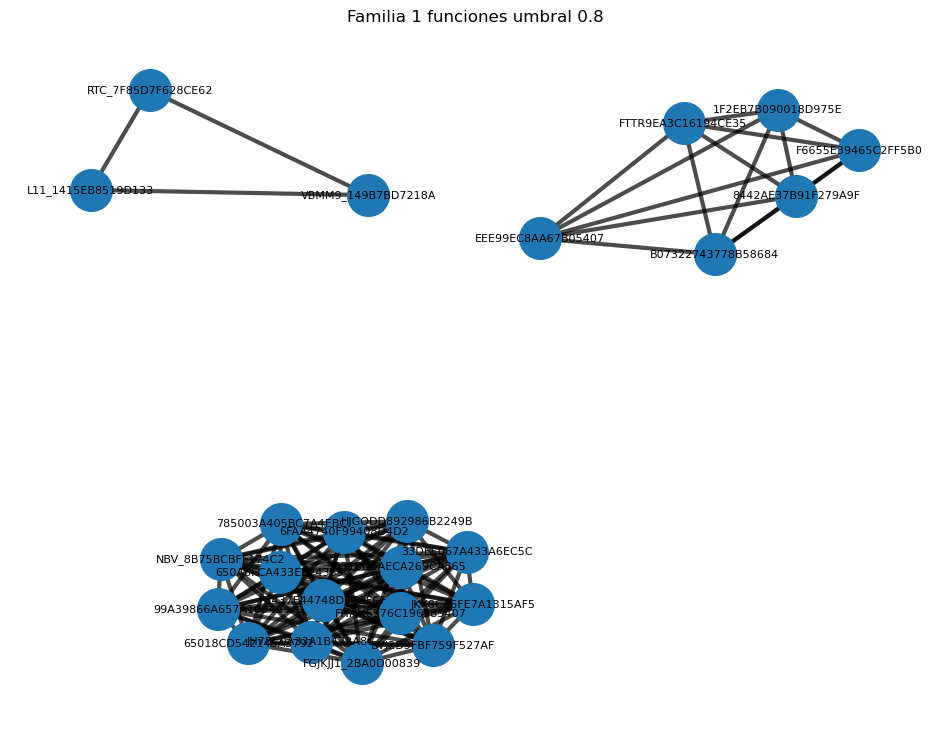

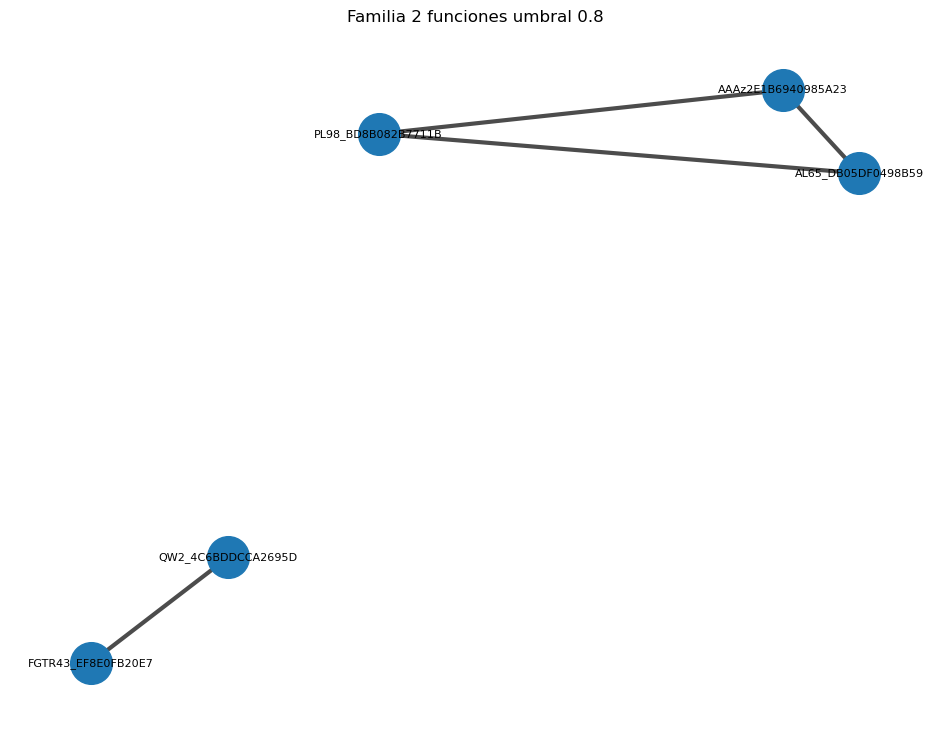

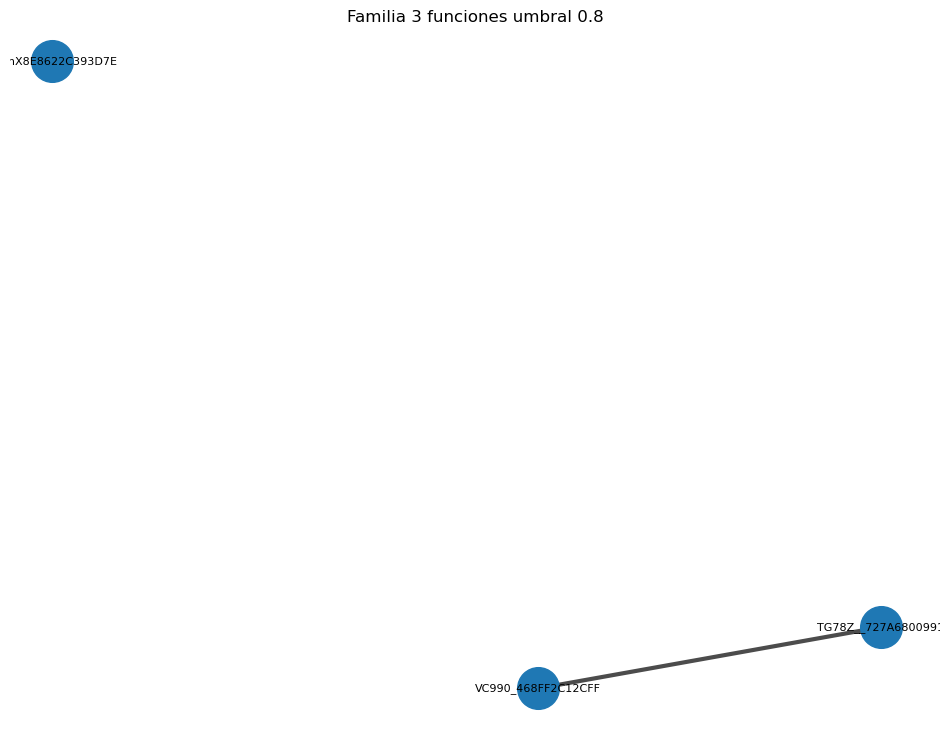

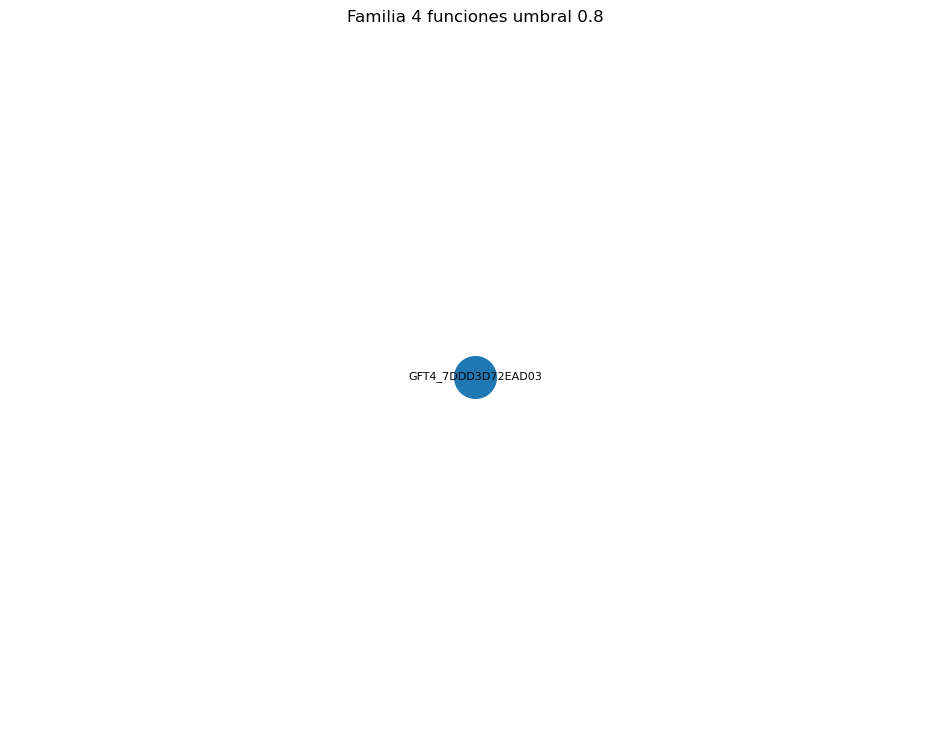

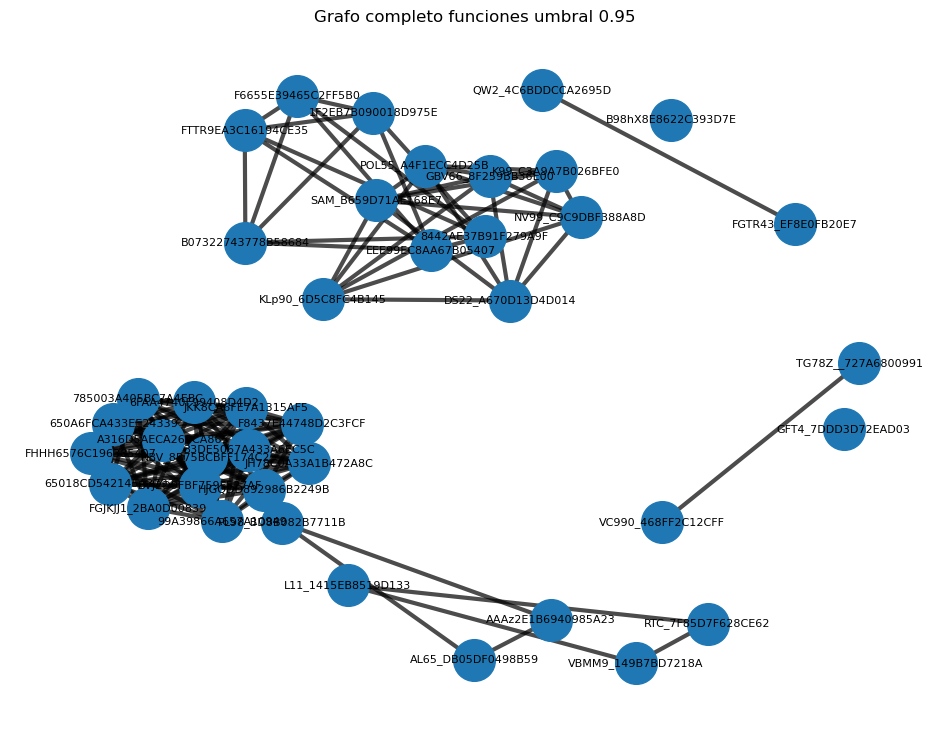

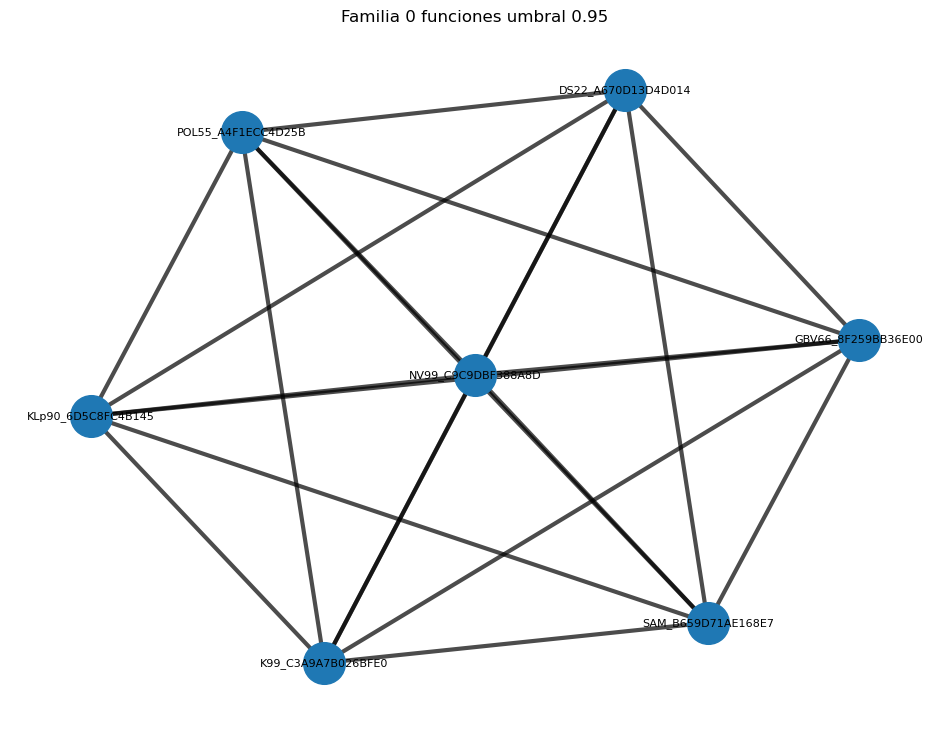

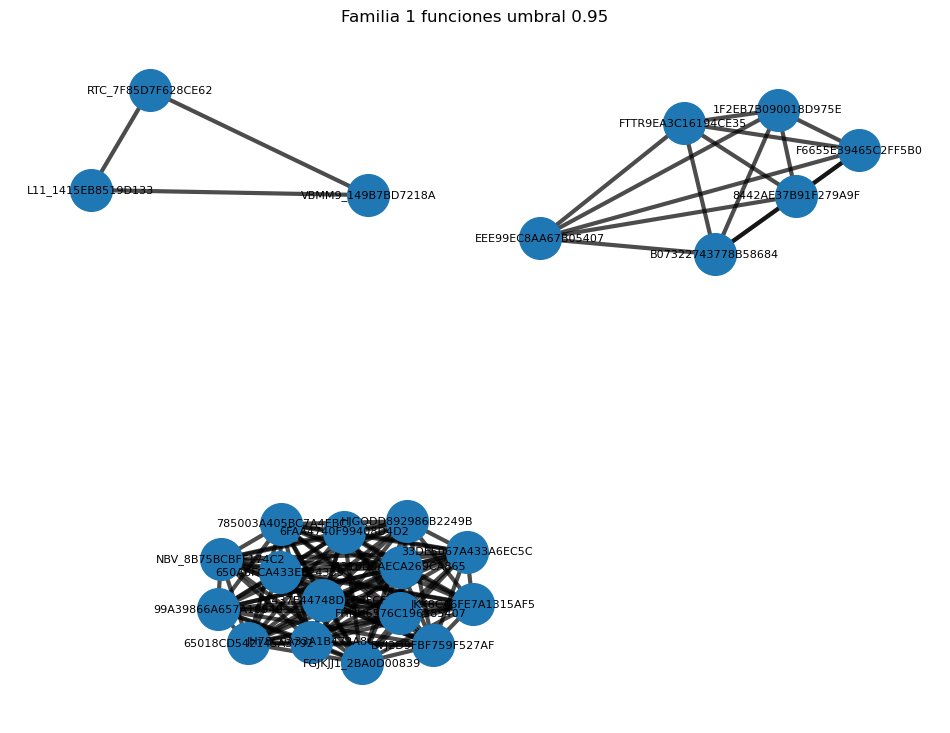

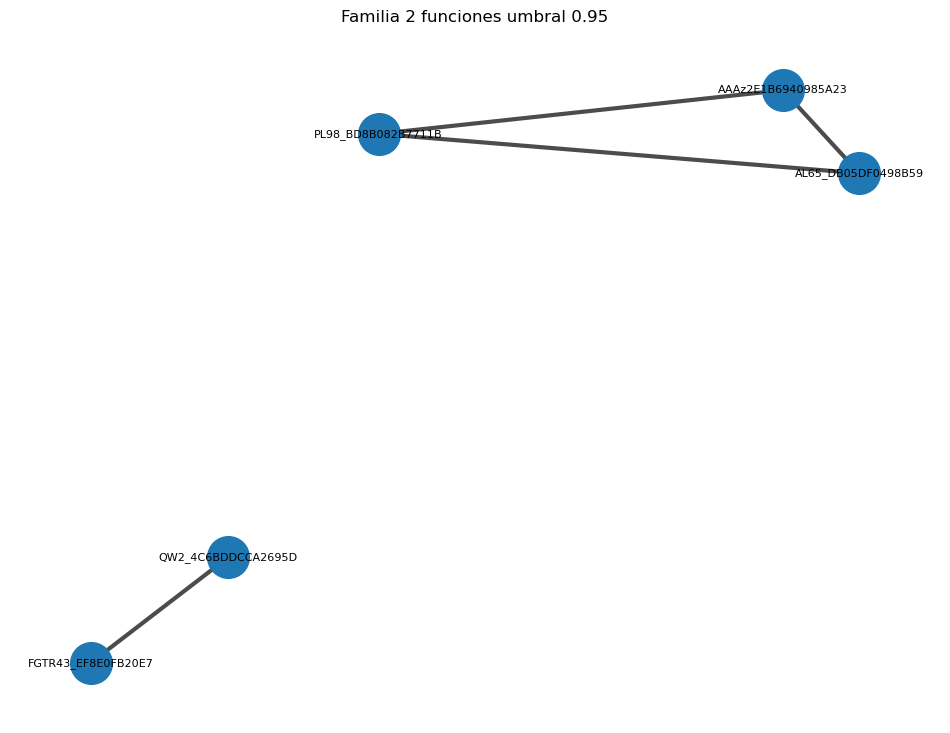

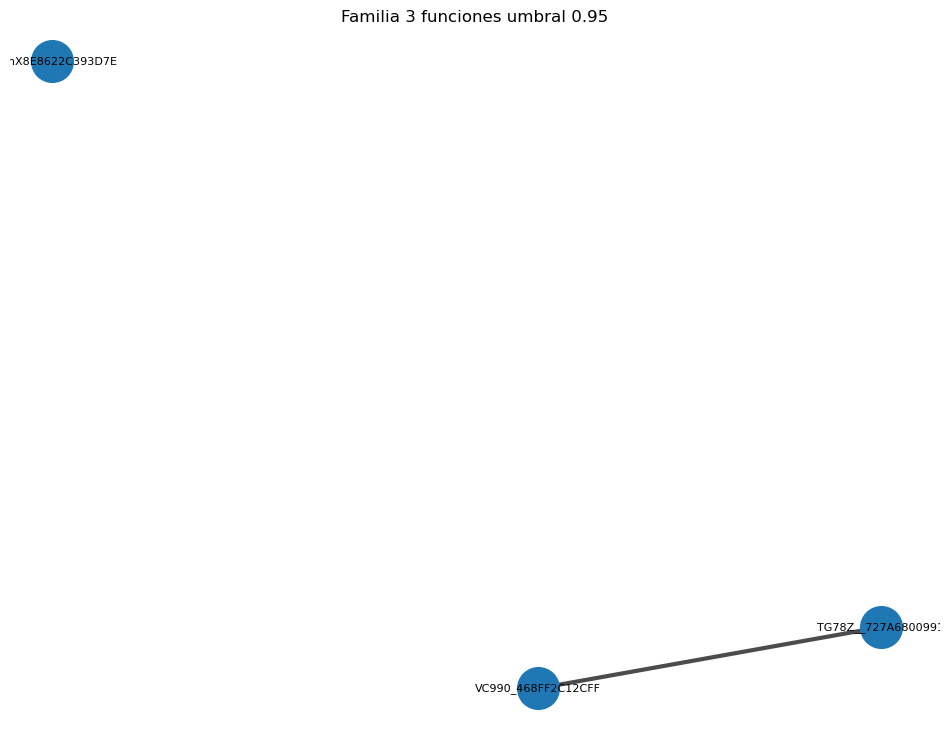

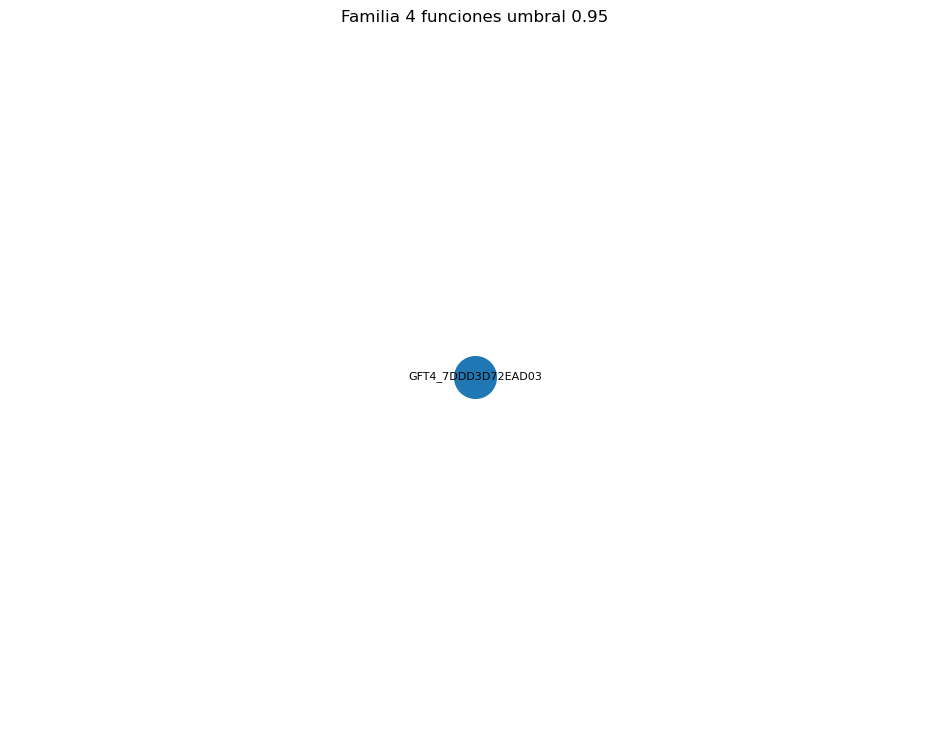

Grafos generados en: ./salidasLab3/grafos


In [ ]:
# se imprimen ya los grafos a generar y se ven las utas guardadas
generarTodosLosGrafos(DfDataset, MapaStrings, "strings", ListaUmbrales, RutaGrafos)
generarTodosLosGrafos(DfDataset, MapaFunciones, "funciones", ListaUmbrales, RutaGrafos)

print("Grafos generados en:", RutaGrafos)

# Resumen de familias encontradas y comparacion de caracteristicas

In [ ]:
# se muestra el tamanio de familias encontardas
def resumirFamilias(dataframe: pd.DataFrame) -> pd.DataFrame:
    resumen = (
        dataframe.groupby("clusterFinal")
        .agg(
            cantidadMuestras=("nombreArchivo", "count"),
            tamanoPromedio=("tamanoBytes", "mean"),
            stringsPromedio=("numeroStrings", "mean"),
            importsPromedio=("numeroImports", "mean"),
            entropiaPromedio=("entropiaArchivo", "mean"),
            empaquetados=("empaquetadoHeuristico", "sum"),
        )
        .reset_index()
        .sort_values("clusterFinal")
    )
    return resumen


# se compara si strings o funciones conectan mas por promedio de similitud
def compararCaracteristicas(dataframeStrings: pd.DataFrame, dataframeFunciones: pd.DataFrame) -> pd.DataFrame:
    filas = [{
        "caracteristica": "strings",
        "promedioSimilitud": float(dataframeStrings["similitud"].mean()) if not dataframeStrings.empty else 0.0,
        "medianaSimilitud": float(dataframeStrings["similitud"].median()) if not dataframeStrings.empty else 0.0,
    }, {
        "caracteristica": "funciones",
        "promedioSimilitud": float(dataframeFunciones["similitud"].mean()) if not dataframeFunciones.empty else 0.0,
        "medianaSimilitud": float(dataframeFunciones["similitud"].median()) if not dataframeFunciones.empty else 0.0,
    }]
    return pd.DataFrame(filas)


DfResumenFamilias = resumirFamilias(DfDataset)
DfComparacionCaracteristicas = compararCaracteristicas(DfSimStrings, DfSimFunciones)
RutaResumenFamilias = os.path.join(RutaTablas, "resumenFamilias.csv")
RutaComparacionCaracteristicas = os.path.join(RutaTablas, "comparacionCaracteristicas.csv")
DfResumenFamilias.to_csv(RutaResumenFamilias, index=False, encoding="utf-8")
DfComparacionCaracteristicas.to_csv(RutaComparacionCaracteristicas, index=False, encoding="utf-8")

print("Resumen de familias")
display(DfResumenFamilias)
print("Comparacion de strings vs funciones")
display(DfComparacionCaracteristicas)

Resumen de familias


,clusterFinal,cantidadMuestras,tamanoPromedio,stringsPromedio,importsPromedio,entropiaPromedio,empaquetados
0,0,7,15360.0,252.000000,85.000000,5.835430,0
1,1,24,6592.0,133.916667,7.750000,6.609430,24
2,2,5,324915.2,5266.600000,10.000000,7.888563,5
3,3,3,327168.0,5347.000000,11.666667,7.891756,3
4,4,1,16896.0,254.000000,85.000000,5.650585,0


Comparacion de strings vs funciones


,caracteristica,promedioSimilitud,medianaSimilitud
0,strings,0.182415,0.053073
1,funciones,0.380391,0.250000


# Reporte final con respuestas del analisis



## Proceso realizado

1. Creacion del dataset

Se construyo un dataset. Para cada muestra se extrajeron strings ASCII, funciones importadas, dlls, secciones y metadatos PE como tamano, numero de secciones, imports, recursos, entropia y heuristica de empaquetado. El dataset final contiene 40 muestras.

2. Preprocesamiento

Se aplico preprocesamiento mixto. Las columnas numericas fueron escaladas con StandardScaler y las columnas textuales fueron vectorizadas con TF IDF usando un documento combinado de strings, funciones, dlls, secciones y rasgos de cabecera PE. Esto permitio que los algoritmos no supervisados trabajaran con datos heterogeneos.

3. KMeans

El mayor coeficiente de silhouette para KMeans fue 0.7619 con K=5.

4. KMedoids

El mayor coeficiente de silhouette para KMedoids fue 0.7619 con K=5.

5. Metodo del codo contra silhouette

Imagenes se encuentran en su carpeta correspondeinte.
Los valores con mejor silhouette fueron K=5 para KMeans y K=5 para KMedoids.

6. Numero estimado de familias

Segun el mejor algoritmo final, se selecciono KMeans con K=5. Por lo tanto, la mejor estimacion de familias de malware en este conjunto es 5.

7. Embeddings Gemini

Los embeddings de Gemini se comparan visualmente con la grafica de 2D de embeddings y la grafica 2D del algoritmo final. Los grupos de puntos aparecen cercanos entre si en ambas visualizaciones, por lo que hay una coincidencia razonable entre embeddings y clustering clasico.

8. Analisis de strings y funciones

Se calcularon similitudes de Jaccard para strings y funciones. El promedio de similitud para strings fue 0.1824. El promedio de similitud para funciones fue 0.3804. Esto ayuda a determinar cual rasgo conecta mejor a los ejemplares dentro de una familia.

## Comparacion de modelos

Al comparar KMeans y KMedoids, ambos algoritmos dan resultados muy parecidos y llegan a la misma conclusion, el mejor numero de clusters es 5. Los dos alcanzan exactamente el mismo coeficiente de Silhouette maximo, 0.761, cuando K=5, lo cual da mucha confianza en que esa cantidad representa las familias presentes en el conjunto de malware. En general, KMeans y KMedoids coinciden en la estructura global de los datos, pero KMeans fue elegido como modelo final porque mantiene el mismo mejor resultado y ademas es mas simple y directo para trabajar en este caso. Tambien se observa que la sseparacion entre grupos mejora bastante de K=2 a K=5, y luego empieza a perder estabilidad, por lo que 5 clusters parece ser el punto mas equilibrado. En la parte de similitud, las llamadas a funciones reflejan mejor las relaciones entre muestras que los strings, ya que su similitud promedio es mayor. En fin, los resultados de particionamiento, embeddings y similitud apuntan a una estructura consistente de 5 familias de malware.


1. Para ambos algoritmos de particionamiento, ¿para qué número de clústeres se obtiene el coeficiente de Silhouette mas alto?

Para ambos algoritmos, KMeans y KMedoids, el coeficiente de Silhouette mas alto se obtiene con K=5. En ambos casos el valor máximo fue 0.761. Esto dice que, entre los valores probados, 5 clusters es la mejor opción para separar las muestras de manera mas clara y coherente.

2. Para ambos algoritmos de particionamiento, ¿en qué medida coincide el coeficiente de Silhouette con el método del codo?

Si coinciden. Aunque el metodo del codo se necesita una inerpretacion visual, en ambos algoritmos se observa una reduccion fuerte del error hasta llegar cerca de K=5, y a partir de ahi la mejora ya no es tan marcada. Al mismo tiempo, el coeficiente de Silhouette también alcanza su mejor valor justamente en K=5. Por lo tanto, ambos criterios apuntan hacia la misma conclusion.

3. Según los resultados obtenidos de ambos algoritmos de particionamiento, ¿cuántas familias cree que existen entre los ejemplares de malware proporcionados?

Con base en los resultados de ambos algoritmos, la mejor estimación es que existen 5 familias de malware en el conjunto analizado. Esta conclusion se basa en que KMeans y KMedoids coinciden en el mismo valor de K y en el mismo mejor coeficiente de Silhouette.

4. ¿En qué medida es similar el análisis de la agrupación de los embeddings de Gemini contra los resultados de los algoritmos de particionamiento?

El analisis con embeddings de Gemini es parecido de manera general a los resultados de los algoritmos de particionamiento, porque también permite observar una agrupacion de las muestras en conjuntos diferenciados. No necesariamente la separacion visual es a la de KMeans o KMedoids, pero si sirve como una validacion adicional de que el dataset tiene alguna estructura interna y que las muestras no estan distribuidas al azar. En otras palabras, Gemini refuerza la idea de que si existen grupos naturales dentro del conjunto, y esos grupos son compatibles con el calculo de 5 familias.

5. ¿En qué medida coincide el análisis de similitud con las familias encontradas utilizando los algoritmos de partición, para ambas características, strings y llamadas a las funciones?

El analisis de similitud coincide de forma parcial pero util con las familias encontradas por los algoritmos de particion. En las dos caracteristicas se observan relaciones entre muestras de una misma familia, pero las llamadas a las funciones coinciden mejor con los clusters que los strings. Esto se nota porque la similitud promedio en funciones fue 0.38, mientras que en strings fue 0.182415. Eso lo que dice es que las funciones importadas o llamadas conservan mejor el comportamiento comun entre muestras de una misma familia, mientras que los strings pueden variar mas por configuracion u ofuscacion. Por eso, aunque ambas caracteristicas dan datos, las llamadas a las funciones fueron mas consistentes para respaldar las familias encontradas.